# Situacion 3 - Consolidado De Rubrica

Este notebook consolida la evidencia final de Situacion 3 usando solo archivos dentro de `Entrega_Final/Situacion3`. Incluye entrenamiento ConvLSTM real, ST-Kriging, LOO-CV, Moran Global, LISA, perfiles tipologicos K-Means, mapas finales, limitaciones y KPIs de rubrica.

In [1]:
from pathlib import Path
import hashlib
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

BASE = Path.cwd()
if BASE.name == 'notebooks':
    S3 = BASE.parent
elif (BASE / 'notebooks').exists() and (BASE / 'outputs').exists():
    S3 = BASE
else:
    S3 = Path('/workspace/geovision-cali-hf/Entrega_Final/Situacion3')

MET = S3 / 'outputs' / 'metricas'
VAL = S3 / 'outputs' / 'validacion_covariates_physical_bounds'
MAP = S3 / 'outputs' / 'mapas'
FIG = S3 / 'outputs' / 'figuras'
CKPT = S3 / 'checkpoints' / 'convlstm_covariates_spatial_best.pt'

def read_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))

def md5_file(path):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b''):
            h.update(chunk)
    return h.hexdigest()

def show_json(obj):
    print(json.dumps(obj, indent=2, ensure_ascii=False))

print('Carpeta Situacion 3:', S3)
print('Checkpoint final:', CKPT.relative_to(S3), CKPT.exists())
print('Checkpoint MD5:', md5_file(CKPT) if CKPT.exists() else 'missing')

Carpeta Situacion 3: /workspace/geovision-cali-hf/Entrega_Final/Situacion3
Checkpoint final: checkpoints/convlstm_covariates_spatial_best.pt True
Checkpoint MD5: 4be0b8360b37a6d30ed4c386c9c79d0d


## 1. Entrenamiento ConvLSTM Final

La evidencia final corresponde al entrenamiento espacial covariado. El tensor de entrada usa secuencias de 8 fechas, grilla `48 x 40` y 273 canales: 256 embeddings GeoVisionCLIP/SAE mas covariables espaciales, temporales y de calidad.

In [2]:
conv_summary = read_json(MET / 'summary_convlstm_bidirectional_spatial.json')
show_json({
    'x_shape': conv_summary['x_shape'],
    'y_shape': conv_summary['y_shape'],
    'split': conv_summary['split'],
    'architecture': conv_summary['architecture'],
    'best_epoch': conv_summary['best_epoch'],
    'best_val_loss': conv_summary['best_val_loss'],
    'test_metrics_all': conv_summary['test_metrics_all'],
    'checkpoint_entrega': str(CKPT.relative_to(S3)),
    'checkpoint_md5': md5_file(CKPT),
})

{
  "x_shape": [
    119,
    8,
    273,
    48,
    40
  ],
  "y_shape": [
    119,
    3,
    3,
    48,
    40
  ],
  "split": {
    "train": 83,
    "val": 17,
    "test": 19
  },
  "architecture": {
    "bidirectional": true,
    "input_channels": 273,
    "hidden": 128,
    "kernel": 3,
    "layers": 2,
    "output": "B x 3 x 3 x H x W"
  },
  "best_epoch": 9,
  "best_val_loss": 0.14290568977594376,
  "test_metrics_all": {
    "scope": "all",
    "pollutant": "all",
    "horizon_days": "all",
    "rmse": 7.539575304369847,
    "mae": 5.457334518432617,
    "r2": 0.6999095380306244,
    "n": 501
  },
  "checkpoint_entrega": "checkpoints/convlstm_covariates_spatial_best.pt",
  "checkpoint_md5": "4be0b8360b37a6d30ed4c386c9c79d0d"
}


,epoch,train_loss,val_loss,val_rmse,val_mae,val_r2,val_n
0,1,0.600315,0.246577,7.291681,5.180315,0.520646,486
1,2,0.419157,0.214718,6.813546,5.177274,0.581450,486
2,3,0.385764,0.202422,6.610174,4.604934,0.606063,486
3,4,0.330527,0.213765,6.798397,4.434260,0.583309,486
4,5,0.288745,0.181494,6.266578,4.192719,0.645952,486
5,6,0.229900,0.150138,5.710293,3.950148,0.706020,486
6,7,0.215767,0.170102,6.065972,4.187546,0.668257,486
7,8,0.194954,0.154727,5.782423,4.161407,0.698546,486
8,9,0.197321,0.142906,5.560543,3.959960,0.721237,486
9,10,0.193763,0.158643,5.863709,4.109994,0.690012,486


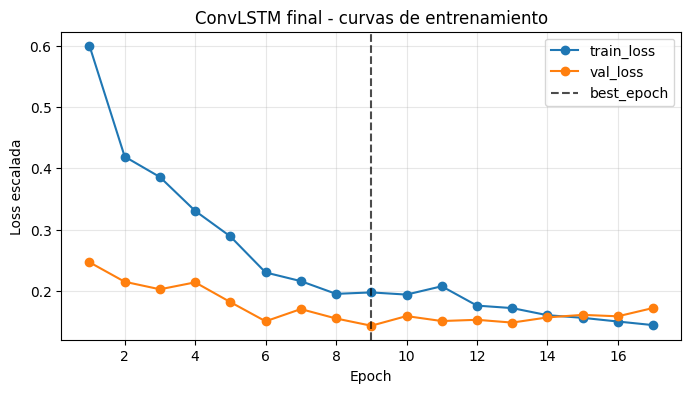

In [3]:
hist = pd.read_csv(MET / 'training_history.csv')
display(hist)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hist['epoch'], hist['train_loss'], marker='o', label='train_loss')
ax.plot(hist['epoch'], hist['val_loss'], marker='o', label='val_loss')
ax.axvline(conv_summary['best_epoch'], color='black', linestyle='--', alpha=0.7, label='best_epoch')
ax.set_title('ConvLSTM final - curvas de entrenamiento')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss escalada')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

In [4]:
test_metrics = pd.read_csv(MET / 'test_metrics_masked.csv')
display(test_metrics)

,scope,pollutant,horizon_days,rmse,mae,r2,n
0,all,all,all,7.539575,5.457335,0.699910,501
1,pollutant,NO2,all,9.172060,9.087623,-85.280556,6
2,pollutant,SO2,all,4.950907,3.302065,0.029091,237
3,pollutant,O3,all,9.268908,7.352749,0.216772,258
4,horizon,all,1,7.882140,5.631147,0.725620,167
5,horizon,all,3,7.090847,5.008711,0.699591,166
6,horizon,all,7,7.621065,5.727839,0.667019,168
7,pollutant_horizon,NO2,1,7.697184,7.696972,-1342.729126,2
8,pollutant_horizon,SO2,1,3.795170,2.723177,0.057713,80
9,pollutant_horizon,O3,1,10.349560,8.319451,0.311533,85


**Interpretacion.** El ConvLSTM final alcanza `RMSE=7.54`, `MAE=5.46` y `R2=0.700` en test agregado antes del ajuste geoestadistico. Esto indica que la red aprende estructura temporal y espacial util a partir de embeddings y covariables. El cierre de rubrica se evalua con LOO-CV espacial y ST-Kriging sobre SO2/O3.

## 2. LOO-CV Espacial Y KPIs De Rubrica

La validacion espacial final usa SO2 y O3 porque tienen soporte suficiente de estaciones. NO2 se reporta como no evaluable en LOO-CV espacial debido a que solo hay una estacion disponible; forzar LOO con `n=1` no seria defendible.

In [5]:
kpi = pd.read_csv(MET / 'kpi_situacion3_physical_bounds_summary.csv')
display(kpi)

loo = pd.read_csv(VAL / 'loo_spatial_metrics_summary.csv')
display(loo)

,kpi,minimum,excellent,value,status,evidence
0,RMSE LOO-CV NO2 T+1,<= 8 ug/m3,<= 4 ug/m3,NaN,no_evaluable,NO2 tiene una sola estacion; LOO-CV espacial n...
1,RMSE LOO-CV SO2 T+1,<= 6 ug/m3,<= 3 ug/m3,3.894846997410492,cumple_minimo,LOO-CV covariado con ST-Kriging y postproceso ...
2,RMSE LOO-CV O3 T+1,<= 12 ug/m3,<= 6 ug/m3,8.51537792795325,cumple_minimo,LOO-CV covariado con ST-Kriging y postproceso ...
3,R2 LOO-CV promedio contaminantes evaluables,>= 0.55,>= 0.75,0.8068909381112621,excelente,Calculado sobre SO2+O3 con la misma regla fisi...
4,Indice Moran I predicciones,"> 0.30, p < 0.05","> 0.50, p < 0.05",min I=0.898; max p=0.001; 9/9 mapas,excelente,Moran I recalculado sobre mapas finales fisica...
5,Variograma residuos nugget puro / sin estructura,sin estructura,sin estructura,1/6 sin estructura en SO2/O3 LOO fisico,no_cumple,Clasificacion distancia-semivarianza sobre res...
6,Cobertura cinturon 95% sigma kriging,>= 92%,>= 95%,0.938513768389287,cumple_minimo,Empirico LOO-CV SO2+O3 usando |obs-pred_fisica...
7,Degradacion T+1 a T+7 RMSE,< 60% aumento,< 30% aumento,-0.016356056890268866,excelente,Ratio RMSE corregido fisicamente T+7/T+1 sobre...
8,Latencia inferencia end-to-end,< 8 s,< 3 s,28.75 ms,excelente,Mediana de 5 repeticiones por radius medida al...


,scope,pollutant,horizon_days,base_rmse,base_mae,base_r2,base_n,corrected_rmse,corrected_mae,corrected_r2,corrected_n,coverage_95_sigma_kriging
0,pollutant_horizon,SO2,1,3.865554,2.364179,0.792862,403,3.894847,2.447499,0.789710,403,0.945409
1,pollutant_horizon,SO2,3,3.845903,2.426599,0.789909,403,3.739748,2.429860,0.801346,403,0.925558
2,pollutant_horizon,SO2,7,3.877460,2.415905,0.801108,411,3.831143,2.422366,0.805831,411,0.941606
3,pollutant_horizon,O3,1,8.579907,6.496784,0.439783,481,8.515378,6.411868,0.448178,481,0.939709
4,pollutant_horizon,O3,3,7.517895,5.922810,0.505342,479,7.347815,5.764494,0.527471,479,0.939457
5,pollutant_horizon,O3,7,7.924421,6.262158,0.486061,474,7.880505,6.162138,0.491741,474,0.938819
6,pollutant,SO2,all,3.863090,2.402317,0.794820,1217,3.822500,2.433170,0.799109,1217,0.937551
7,pollutant,O3,all,8.020489,6.227505,0.475874,1434,7.929959,6.113078,0.487640,1434,0.939331
8,all,SO2+O3,all,6.453518,4.471468,0.802508,2651,6.381503,4.423735,0.806891,2651,0.938514


**Interpretacion.** SO2 cumple el umbral minimo con `RMSE T+1=3.895 ug/m3` y O3 cumple con `RMSE T+1=8.515 ug/m3`. El `R2` promedio sobre contaminantes evaluables es `0.807`, nivel excelente. La cobertura empirica del cinturon de incertidumbre Kriging es `93.85%`, por encima del minimo de 92%. La latencia end-to-end es excelente: `28.75 ms` como mediana de 5 repeticiones por radius, medida con `time.perf_counter` en `/api/situacion3/radius`.

## 3. Variogramas De Residuos

La rubrica pide que el variograma residual sea nugget puro o sin estructura. Esta condicion se reporta de forma estricta y no se maquilla.

In [6]:
vg = pd.read_csv(VAL / 'variogram_residual_structure_classification.csv')
display(vg)

vario = pd.read_csv(VAL / 'experimental_variograms_corrected_loo.csv')
display(vario.head())

,pollutant,horizon_days,distance_semivariance_corr,relative_semivariance_change,classification
0,O3,1,0.283200,-0.147918,sin_estructura_nugget_puro
1,O3,3,0.734537,0.076180,estructura_residual_detectable
2,O3,7,0.859251,0.201763,estructura_residual_detectable
3,SO2,1,0.817755,1.062037,estructura_residual_detectable
4,SO2,3,0.807655,0.504550,estructura_residual_detectable
5,SO2,7,0.791491,1.033277,estructura_residual_detectable


,pollutant,horizon_days,bin,distance_min,distance_max,distance_mean,semivariance,n_pairs
0,O3,1,0,0.000684,0.022424,0.010847,59.808504,1075
1,O3,1,1,0.022424,0.044163,0.034495,62.103844,1869
2,O3,1,2,0.044163,0.065902,0.053968,53.342299,2701
3,O3,1,3,0.065902,0.087641,0.079550,66.674991,3506
4,O3,1,4,0.087641,0.109380,0.097203,76.507334,3352


**Interpretacion.** El criterio de nugget puro no se cumple globalmente: solo `1/6` combinaciones SO2/O3 por horizonte queda clasificada como `sin_estructura_nugget_puro`. Esto significa que el pipeline captura patrones utiles y cumple varios KPIs, pero todavia deja autocorrelacion residual en varias combinaciones contaminante-horizonte. La conclusion defendible es que el modelo es operacionalmente util, aunque el cierre geoestadistico no es perfecto.

## 4. Moran Global

Moran I evalua si las superficies predichas tienen coherencia espacial global. La rubrica espera `I > 0.30` con `p < 0.05`.

In [7]:
moran = pd.read_csv(MAP / 'moran_global_by_pollutant_horizon.csv')
display(moran)
print('I minimo:', moran['moran_i'].min())
print('p maximo:', moran['p_sim'].max())

,pollutant,horizon_days,moran_i,expected_i,p_sim,z_sim,n,status
0,NO2,1,0.929225,-0.000521,0.001,81.432597,1920,ok
1,NO2,3,0.956662,-0.000521,0.001,86.352258,1920,ok
2,NO2,7,0.897695,-0.000521,0.001,79.092898,1920,ok
3,SO2,1,0.912928,-0.000521,0.001,80.425267,1920,ok
4,SO2,3,0.948293,-0.000521,0.001,85.821169,1920,ok
5,SO2,7,0.930228,-0.000521,0.001,83.481969,1920,ok
6,O3,1,0.918941,-0.000521,0.001,79.976337,1920,ok
7,O3,3,0.924978,-0.000521,0.001,85.369589,1920,ok
8,O3,7,0.917832,-0.000521,0.001,81.226628,1920,ok


I minimo: 0.8976953895863123
p maximo: 0.001


**Interpretacion.** Los 9 mapas son significativos (`p=0.001`) y el menor Moran I es `0.898`, muy por encima del umbral de rubrica. Esto indica que las predicciones no son ruido punto a punto: forman superficies espacialmente coherentes con gradientes continuos, requisito clave para mapas urbanos interpretables.

## 5. LISA Local

LISA identifica clusters locales significativos. Permite distinguir celdas `high_high`, `low_low`, outliers locales y zonas sin asociacion significativa.

In [8]:
lisa = pd.read_csv(MAP / 'lisa_local_clusters_long.csv')
lisa_summary = lisa.groupby(['pollutant', 'horizon_days', 'lisa_cluster']).size().rename('n').reset_index()
display(lisa_summary)
display(lisa[lisa['significant']].head())

,pollutant,horizon_days,lisa_cluster,n
0,NO2,1,high_high,615
1,NO2,1,low_low,524
2,NO2,1,not_significant,781
3,NO2,3,high_high,591
4,NO2,3,high_low,1
5,NO2,3,low_low,543
6,NO2,3,not_significant,785
7,NO2,7,high_high,523
8,NO2,7,low_low,539
9,NO2,7,not_significant,858


,pollutant,horizon_days,grid_id,lat,lon,prediction_corrected,kriging_variance,local_i,p_sim,quadrant,significant,lisa_cluster
3,NO2,1,g_001_003,3.3075,-76.5825,9.303707,55.151516,0.368079,0.028,3,True,low_low
4,NO2,1,g_001_004,3.3075,-76.5775,9.235033,53.999058,0.479663,0.015,3,True,low_low
5,NO2,1,g_001_005,3.3075,-76.5725,9.302025,52.937801,0.465665,0.014,3,True,low_low
6,NO2,1,g_001_006,3.3075,-76.5675,9.326198,51.975689,0.470370,0.011,3,True,low_low
7,NO2,1,g_001_007,3.3075,-76.5625,9.218112,51.120758,0.578685,0.008,3,True,low_low


**Interpretacion.** LISA convierte los mapas continuos en evidencia local de clusters. Las zonas `high_high` representan areas donde una celda alta esta rodeada por vecinos altos y, por tanto, sugieren focos persistentes de contaminacion. Las zonas `low_low` representan areas de menor carga relativa. Las celdas `not_significant` no deben interpretarse como focos, aunque tengan valores puntuales altos o bajos.

## 6. Perfiles Tipologicos K-Means

Los perfiles tipologicos agrupan celdas de grilla por comportamiento conjunto de las superficies predichas e incertidumbre. Esto resume zonas urbanas con patrones cronicos semejantes.

In [9]:
clusters = pd.read_csv(MAP / 'kmeans_cluster_summary.csv')
display(clusters.sort_values('risk_rank'))
profiles = pd.read_csv(MAP / 'kmeans_critical_profiles_by_grid.csv')
display(profiles.head())

,cluster,n_cells,mean_prediction_profile,max_prediction_profile,mean_uncertainty_profile,lat_mean,lon_mean,risk_rank
4,4,432,18.060950,38.297096,81.109320,3.486748,-76.479896,1
3,3,221,17.098700,28.882643,102.297502,3.494966,-76.477704,2
2,2,372,14.337492,31.795226,99.677946,3.344973,-76.482997,3
0,0,536,14.096493,34.490131,66.590639,3.384366,-76.531996,4
1,1,359,13.015160,23.991048,50.108718,3.451219,-76.507765,5


,grid_id,lat,lon,NO2_t1_pred,NO2_t1_var,NO2_t3_pred,NO2_t3_var,NO2_t7_pred,NO2_t7_var,SO2_t1_pred,...,O3_t1_pred,O3_t1_var,O3_t3_pred,O3_t3_var,O3_t7_pred,O3_t7_var,cluster,mean_prediction_profile,max_prediction_profile,mean_uncertainty_profile
0,g_001_000,3.3075,-76.5975,11.768238,59.081429,8.640517,55.406994,10.554169,55.606766,10.093141,...,25.229990,95.481850,23.174448,75.212700,18.662770,83.968658,3,14.240586,25.229990,118.274606
1,g_001_001,3.3075,-76.5925,10.478307,57.699745,8.071222,54.079376,9.202508,54.709850,6.529670,...,30.211882,94.692039,28.249623,74.846458,23.829361,83.262596,2,14.415203,30.211882,116.271906
2,g_001_002,3.3075,-76.5875,9.669003,56.387508,8.028012,52.818436,8.839577,53.858936,4.187317,...,32.889806,93.938698,31.055111,74.497063,27.100085,82.589149,2,14.509184,32.889806,114.383792
3,g_001_003,3.3075,-76.5825,9.303707,55.151516,8.062610,51.630714,8.790849,53.058357,2.855953,...,33.859727,93.225296,32.157007,74.166046,28.518756,81.951454,2,14.435593,33.859727,112.615691
4,g_001_004,3.3075,-76.5775,9.235033,53.999058,8.023331,50.523216,8.754494,52.312721,2.415686,...,33.771890,92.555557,32.232674,73.855049,28.640562,81.352867,2,14.296512,33.771890,110.972916


**Interpretacion.** K-Means separa 5 perfiles espaciales. El perfil mas critico es el cluster `4` (`risk_rank=1`), con `mean_prediction_profile=18.06`, maximo `38.30` y centro aproximado `lat=3.4867`, `lon=-76.4799`. El segundo perfil de riesgo es el cluster `3` (`risk_rank=2`), con concentracion media alta y la mayor incertidumbre media, por lo que debe leerse como zona prioritaria pero con cautela. Los clusters con `risk_rank` 4 y 5 tienen menor severidad relativa y funcionan como referencia de fondo urbano.

## 7. Soporte Espacial Por Estaciones E Incertidumbre

La incertidumbre Kriging no se interpreta solo como error numerico: tambien refleja soporte espacial. En general, las zonas mas alejadas de estaciones DAGMA que si miden el contaminante correspondiente tienden a mostrar mayor varianza. Por eso la lectura de cada mapa debe considerar cuantas estaciones aportan evidencia para ese gas y donde estan ubicadas.

In [10]:
stations_by_pollutant = pd.read_csv(MET / 'stations_by_pollutant_s3.csv')
uncertainty_station = pd.read_csv(MET / 'kriging_uncertainty_vs_station_distance.csv')

display(stations_by_pollutant)
display(uncertainty_station)

,pollutant,station,lat,lon,n_records
0,NO2,Univalle,3.377911,-76.533811,26259
1,O3,Base Aerea,3.457128,-76.502303,29093
2,O3,Compartir,3.428260,-76.466584,35056
3,O3,ERA - Obrero,3.457317,-76.506539,26535
4,O3,Flora,3.488218,-76.518058,24327
5,O3,Pance,3.304517,-76.531252,36340
6,O3,TRANSITORIA-NAVARRO,3.417183,-76.494960,5940
7,O3,Univalle,3.377911,-76.533811,33966
8,SO2,Base Aerea,3.457128,-76.502303,23067
9,SO2,Canaveralejo,3.416366,-76.549613,32923


,pollutant,horizon_days,n_stations,nearest_station_km_mean,nearest_station_km_p75,variance_near_q25_mean,variance_far_q75_mean,far_over_near_variance_ratio,distance_variance_corr
0,NO2,1,1,10.821480,14.650753,38.000250,84.830687,2.232372,0.998742
1,NO2,3,1,10.821480,14.650753,35.137134,80.144159,2.280896,0.998759
2,NO2,7,1,10.821480,14.650753,42.128387,72.440821,1.719525,0.998307
3,O3,1,7,5.513269,7.455049,76.007801,90.150429,1.186068,0.748938
4,O3,3,7,5.513269,7.455049,65.852287,72.617592,1.102735,0.605103
5,O3,7,7,5.513269,7.455049,66.799292,79.313555,1.187341,0.768907
6,SO2,1,5,6.595213,9.358724,31.187313,166.866595,5.350464,0.990420
7,SO2,3,5,6.595213,9.358724,32.158045,171.795447,5.342223,0.990490
8,SO2,7,5,6.595213,9.358724,33.269601,174.565350,5.246993,0.990880


**Interpretacion.** NO2 solo tiene soporte directo en Univalle, por eso sus mapas se leen como exploratorios y la incertidumbre aumenta marcadamente al alejarse de esa estacion. SO2 tiene soporte en cinco estaciones y aun asi muestra una relacion fuerte entre distancia a estacion y varianza Kriging; esto explica por que los bordes y zonas menos cubiertas son mas inciertos. O3 tiene mayor soporte espacial con siete estaciones, por lo que su incertidumbre es menos extrema, aunque sigue creciendo en sectores alejados de estaciones. Esta lectura es clave para LISA y K-Means: un cluster de riesgo en una zona distante de estaciones debe interpretarse como prioridad de monitoreo, no como certeza absoluta.

## 8. Mapas Finales

Se exportaron 9 mapas de concentracion corregida, 9 mapas de incertidumbre Kriging, 9 mapas LISA y un mapa K-Means. Estos archivos estan dentro de `outputs/figuras`.

{
  "n_png": 28,
  "out": "Entrega_Final/Situacion3/outputs/figuras"
}


### NO2 - concentracion corregida

**NO2 T+1 - concentracion corregida**

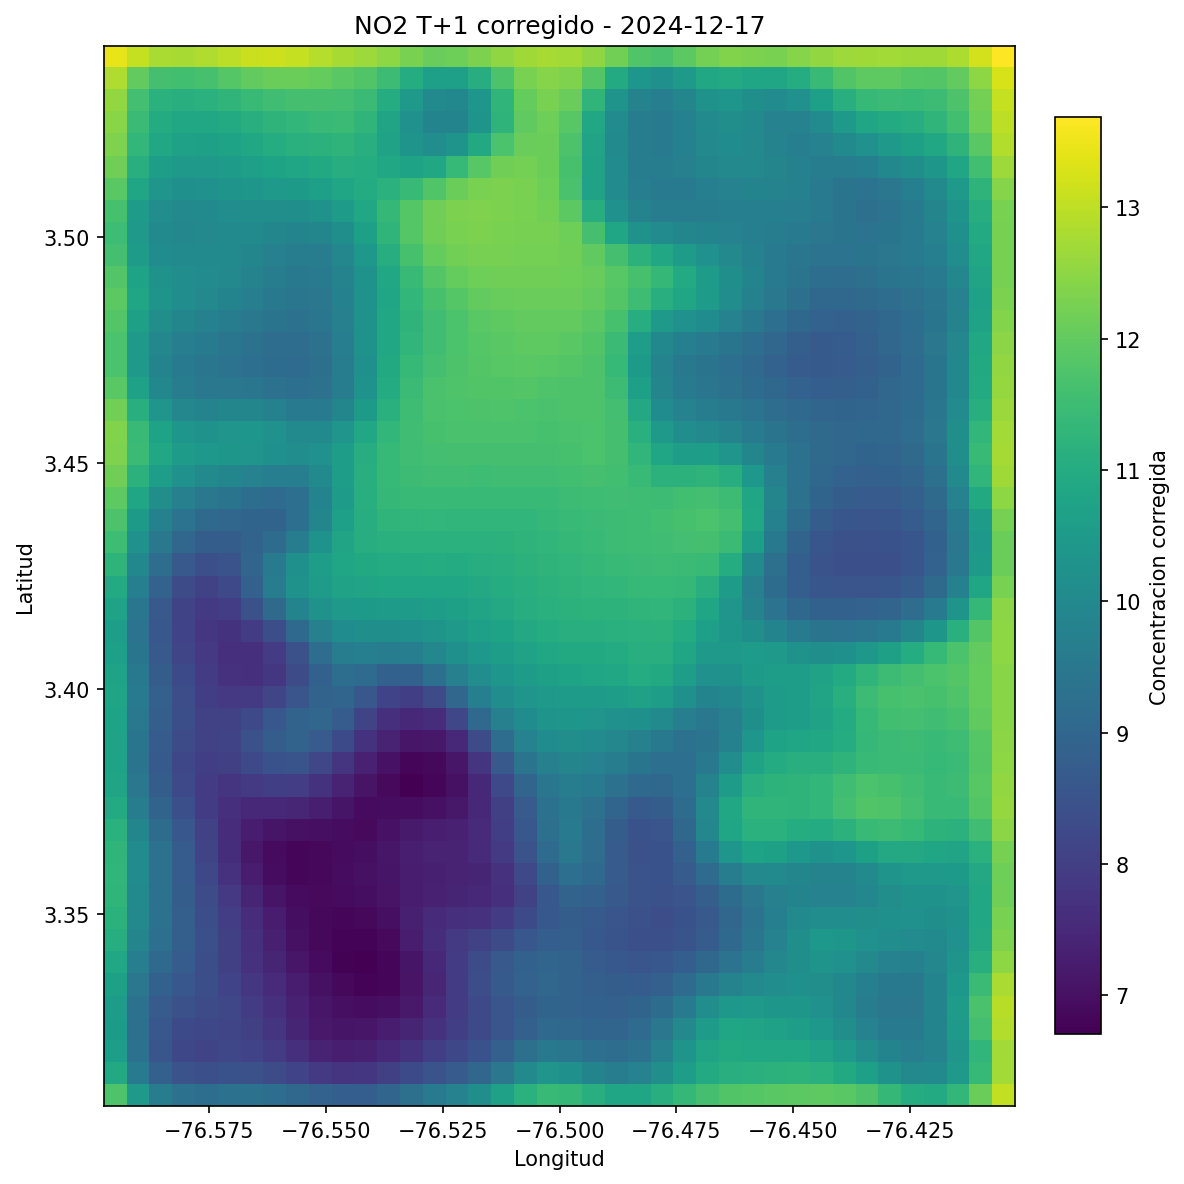

**NO2 T+3 - concentracion corregida**

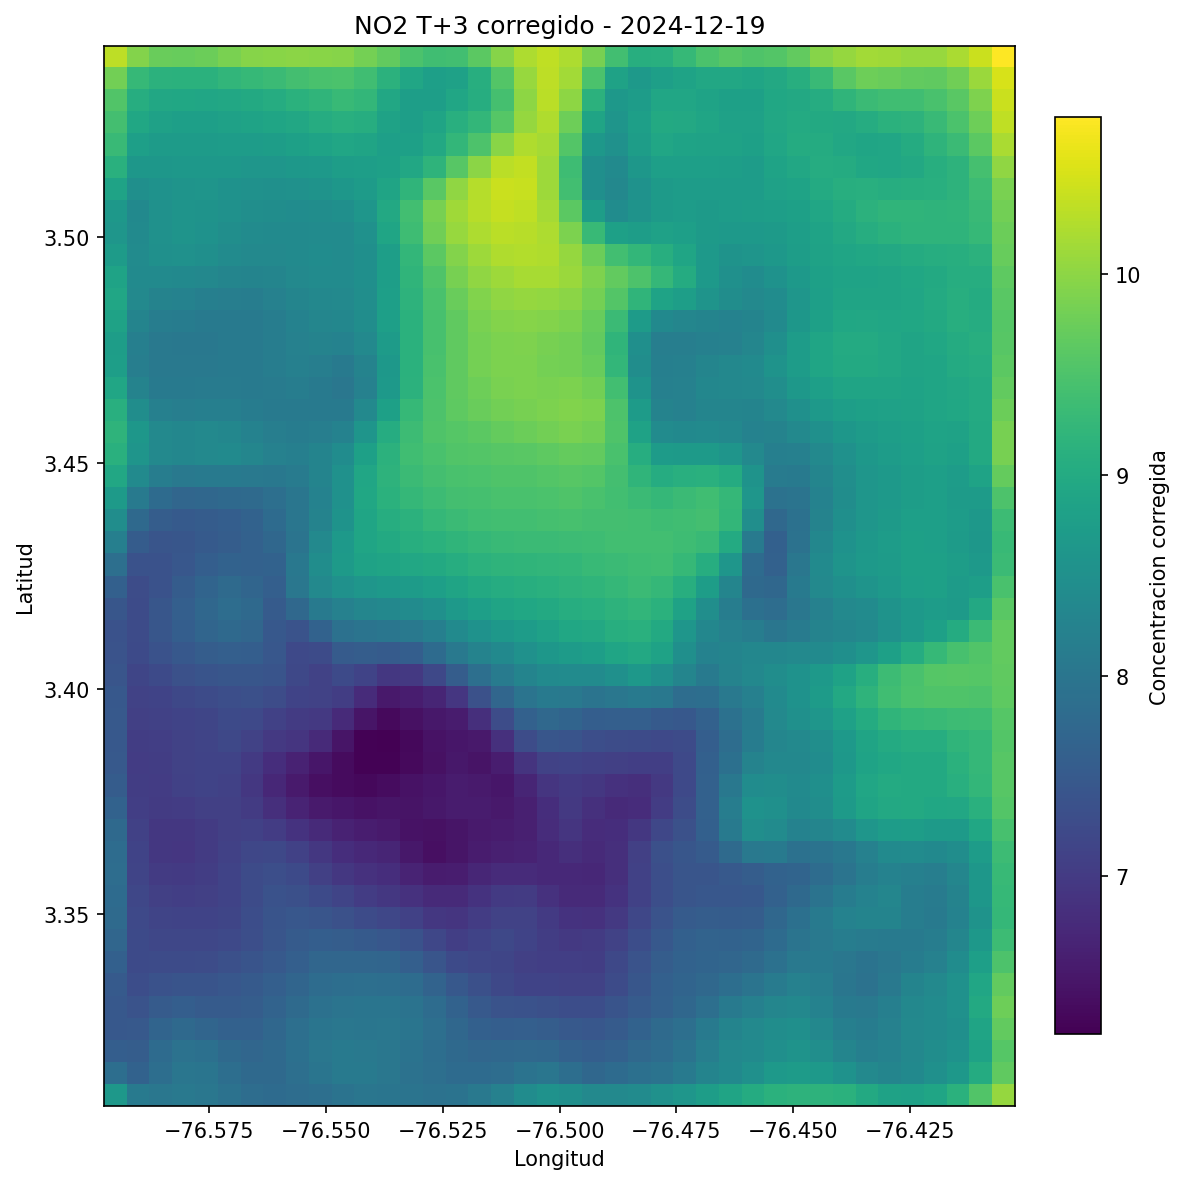

**NO2 T+7 - concentracion corregida**

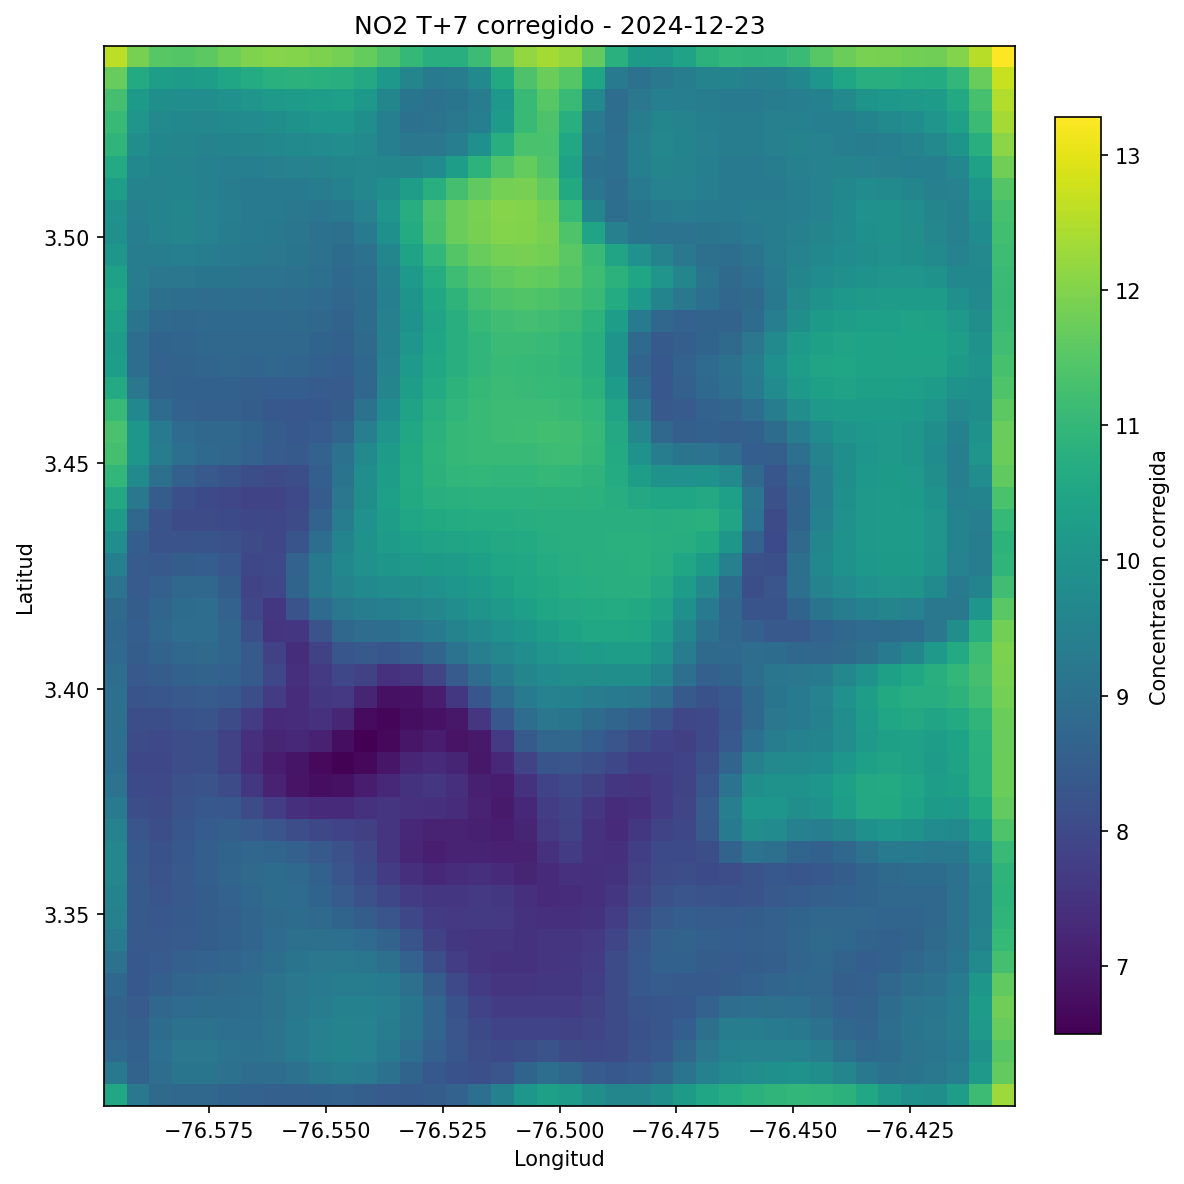

**Interpretacion.** Los tres horizontes de NO2 conservan una estructura espacial persistente, con zonas relativamente altas hacia el norte/nororiente y menores valores hacia el suroccidente. La lectura principal es de patron territorial estable, no de validacion externa fuerte, porque el soporte directo de estaciones para NO2 proviene solo de Univalle.

### SO2 - concentracion corregida

**SO2 T+1 - concentracion corregida**

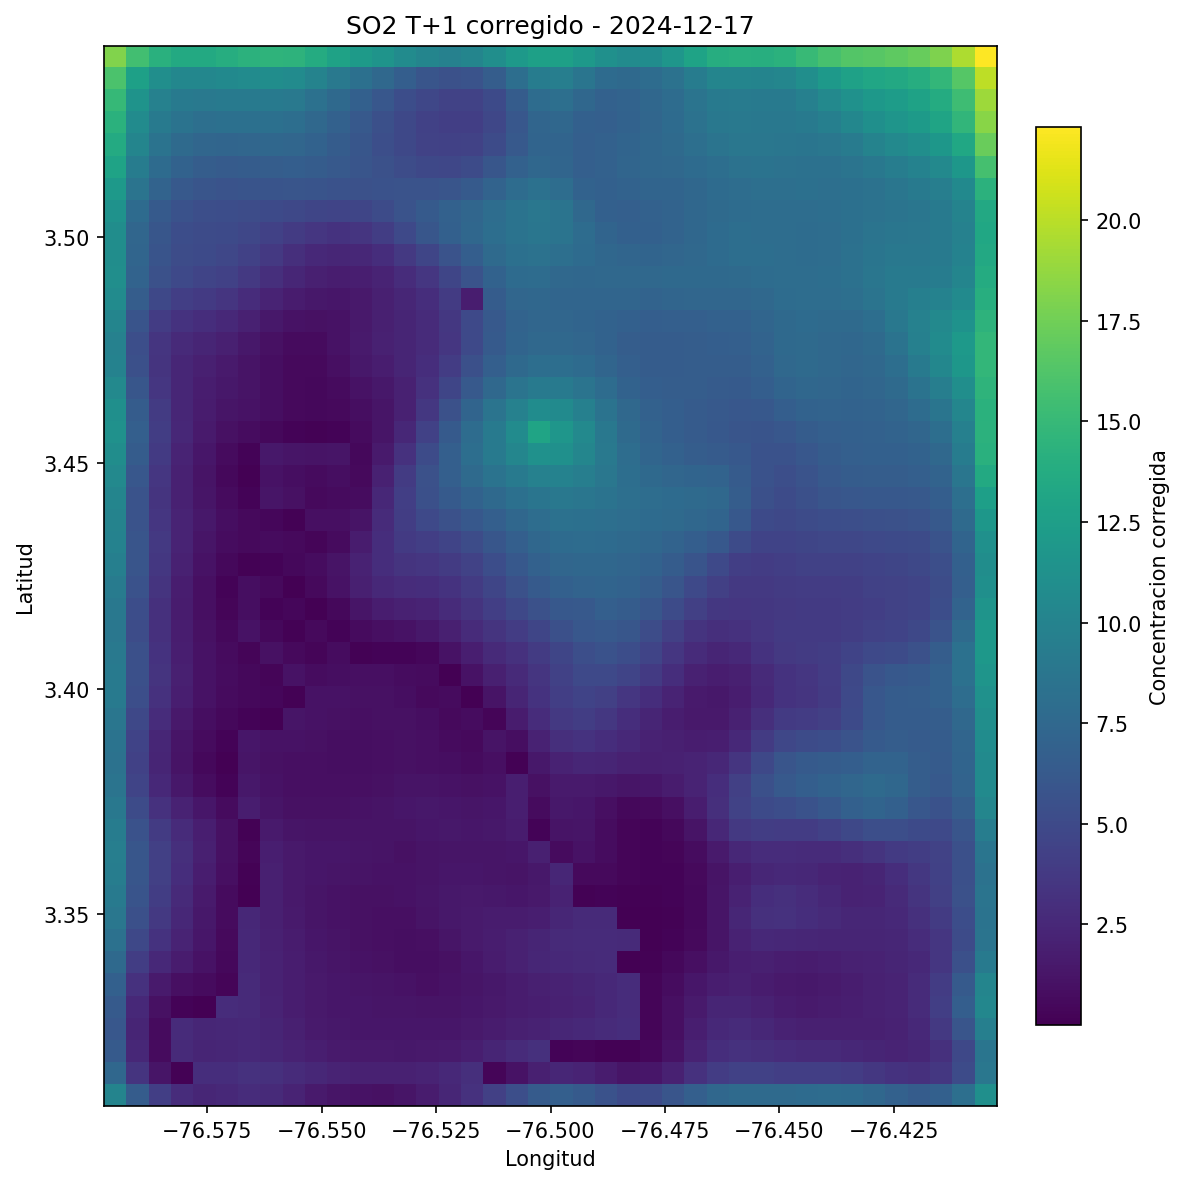

**SO2 T+3 - concentracion corregida**

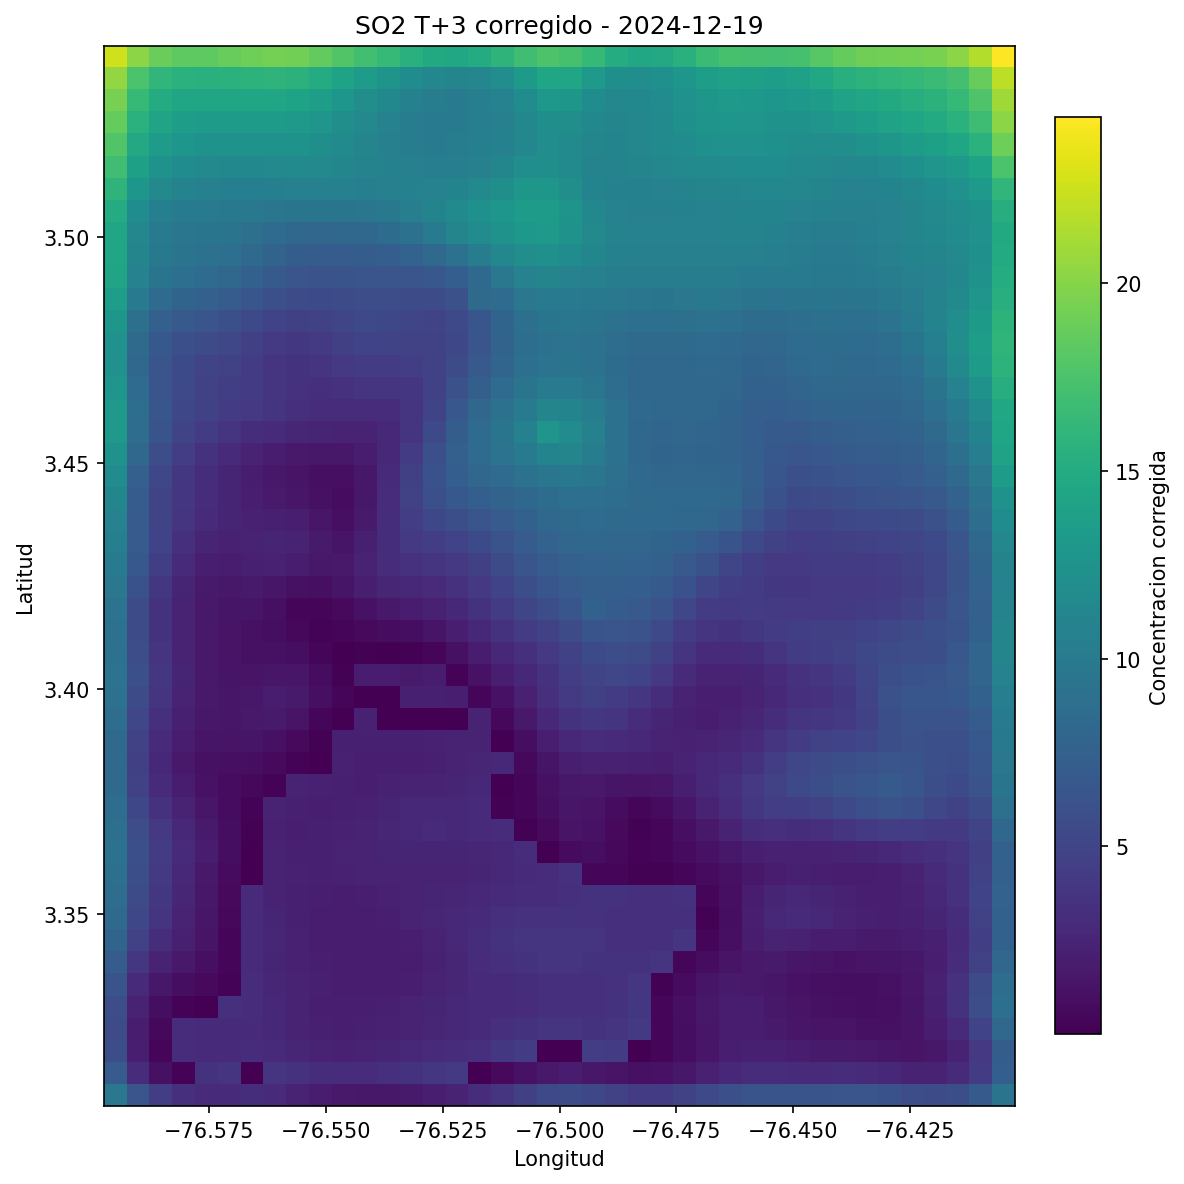

**SO2 T+7 - concentracion corregida**

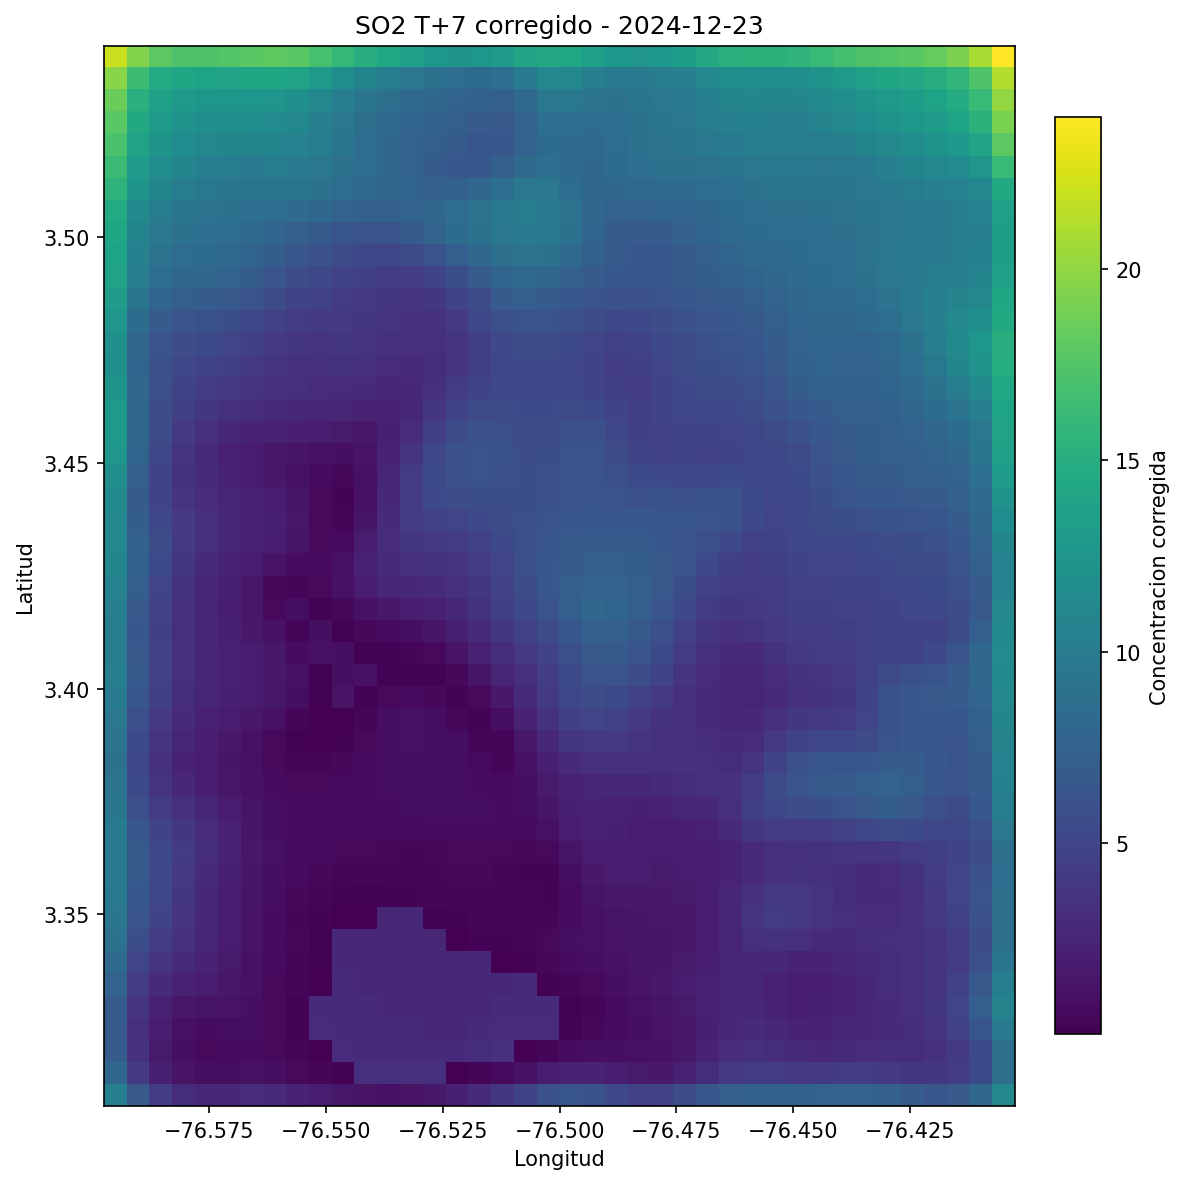

**Interpretacion.** SO2 presenta el patron mas defendible de concentracion corregida: los tres horizontes mantienen un gradiente alto hacia el norte/nororiente y menor carga hacia el suroccidente. Esta lectura es consistente con la validacion LOO-CV y con el contexto del corredor industrial Yumbo/Acopi.

### O3 - concentracion corregida

**O3 T+1 - concentracion corregida**

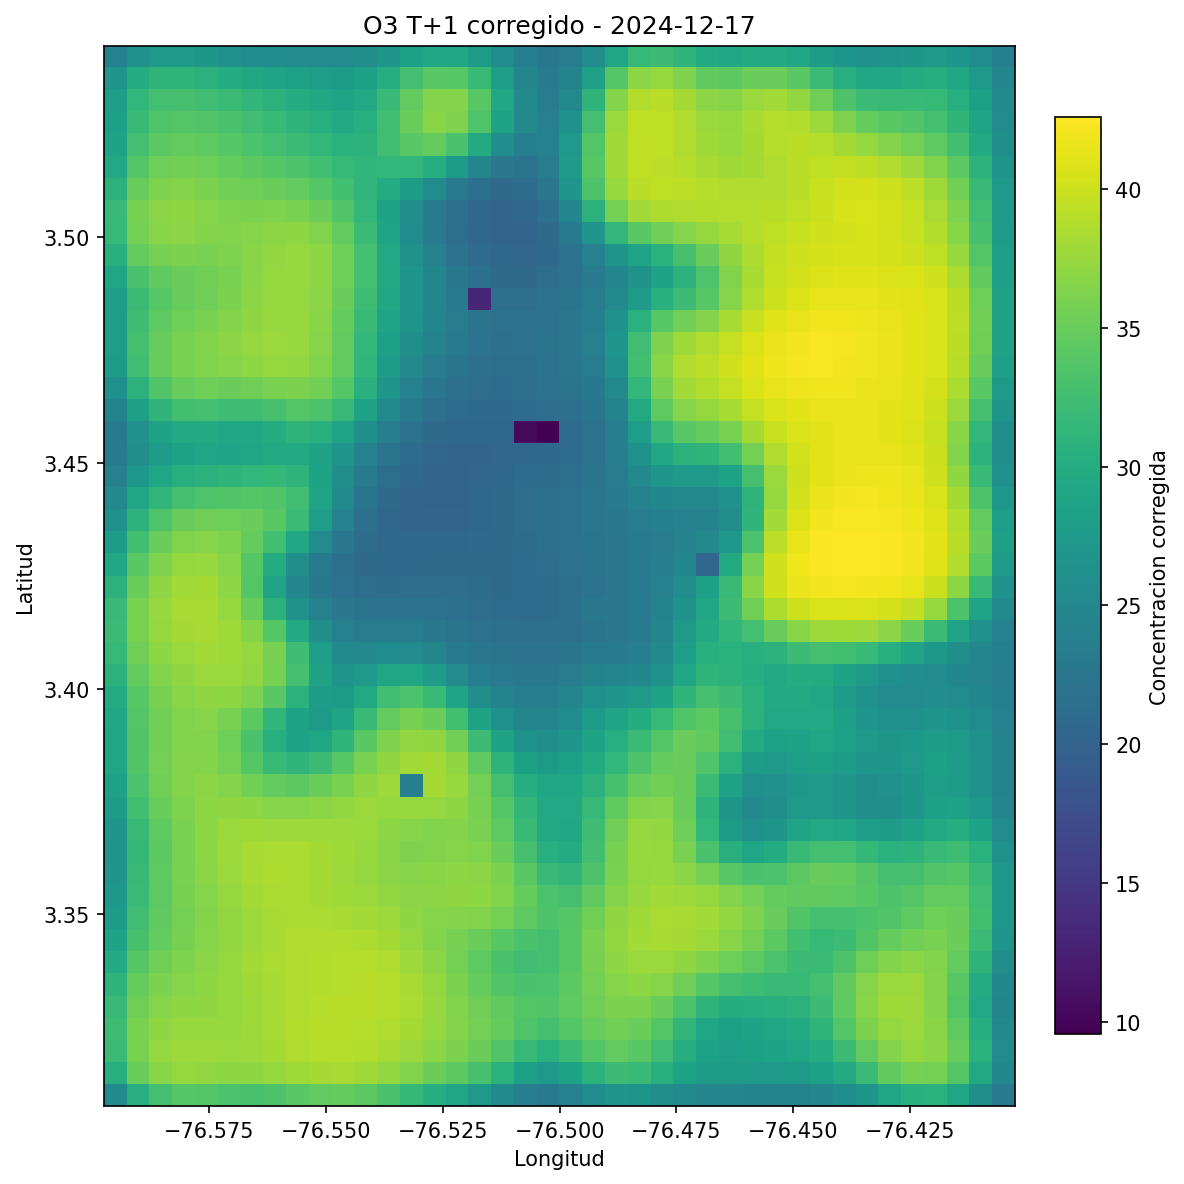

**O3 T+3 - concentracion corregida**

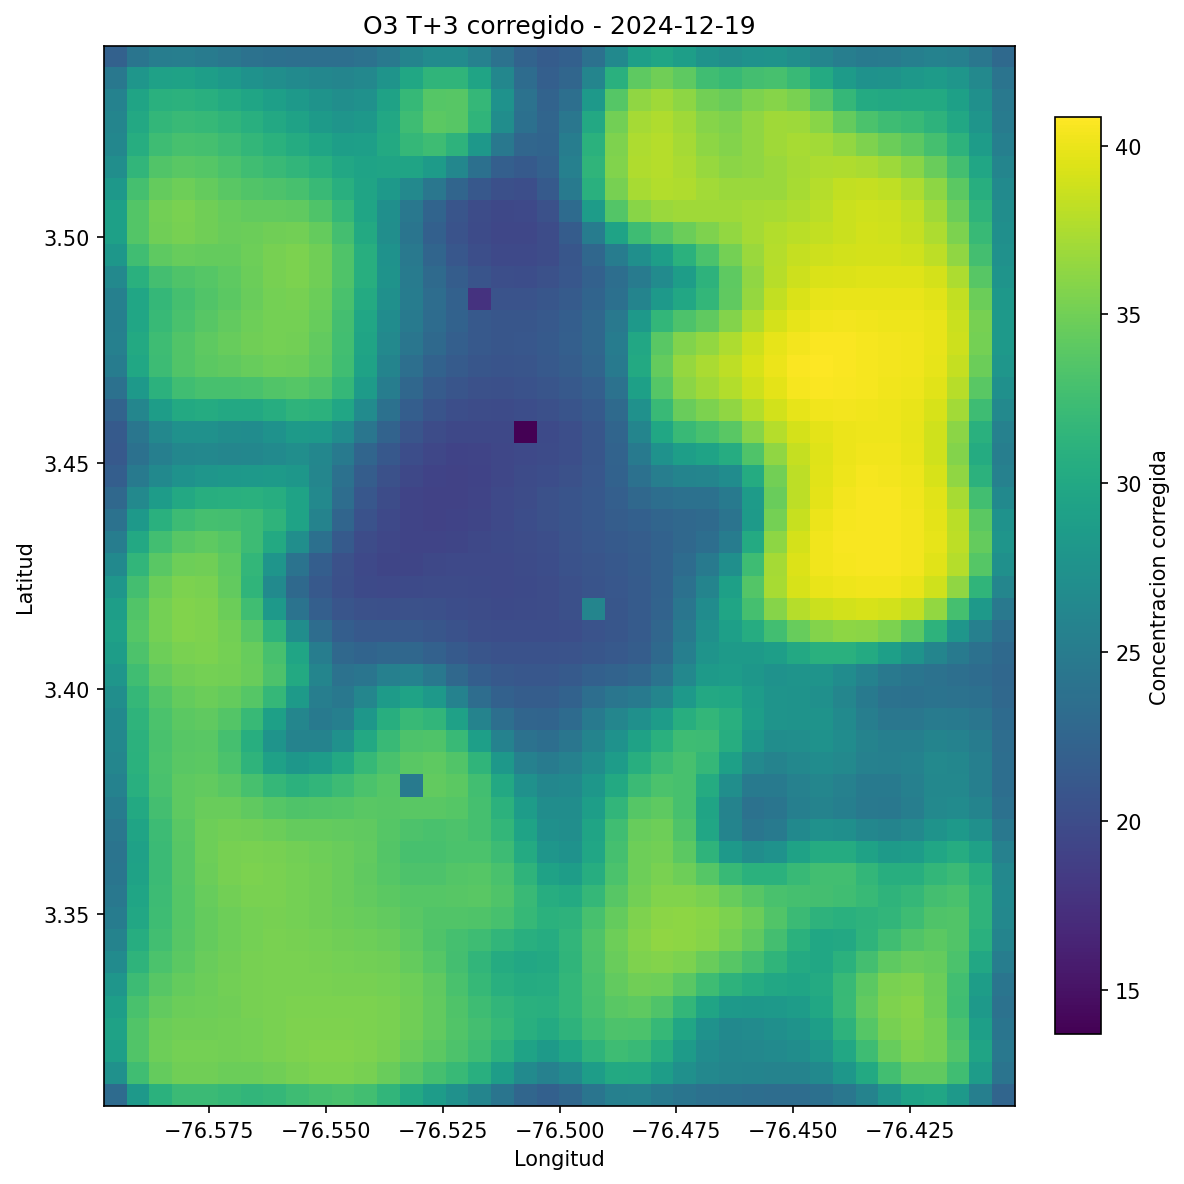

**O3 T+7 - concentracion corregida**

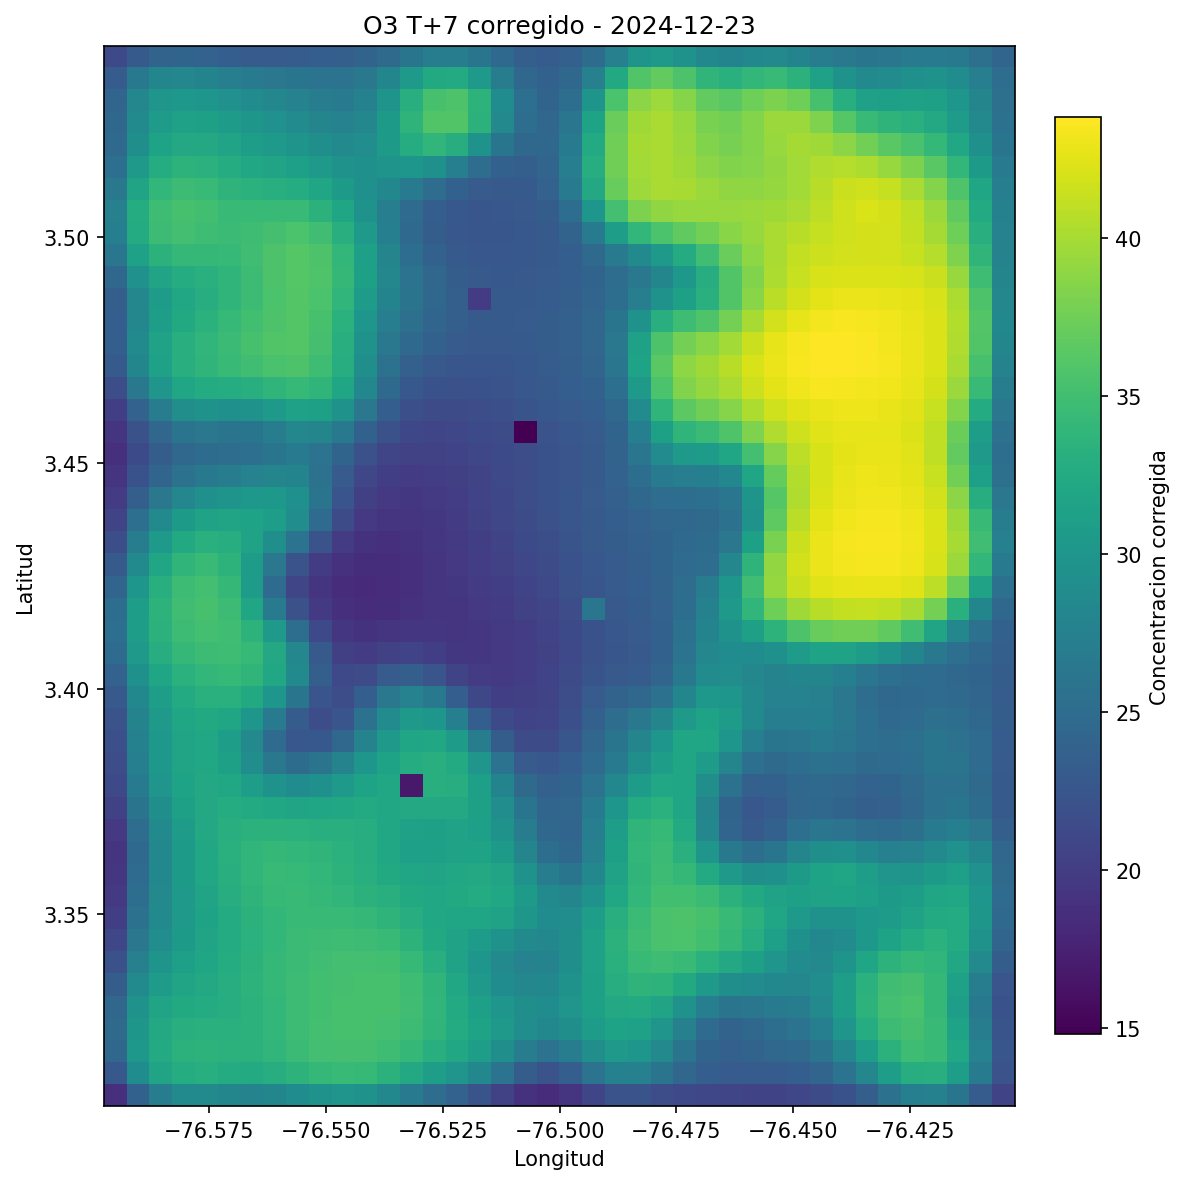

**Interpretacion.** O3 muestra una distribucion mas heterogenea entre horizontes, sin un unico foco dominante. Esto es coherente con su caracter de contaminante secundario, asociado a radiacion, meteorologia, precursores y cobertura de suelo/vegetacion. La interpretacion debe centrarse en acumulacion regional y condiciones ambientales, no en una fuente puntual.

### Incertidumbre Kriging

**NO2 T+1 - varianza Kriging**

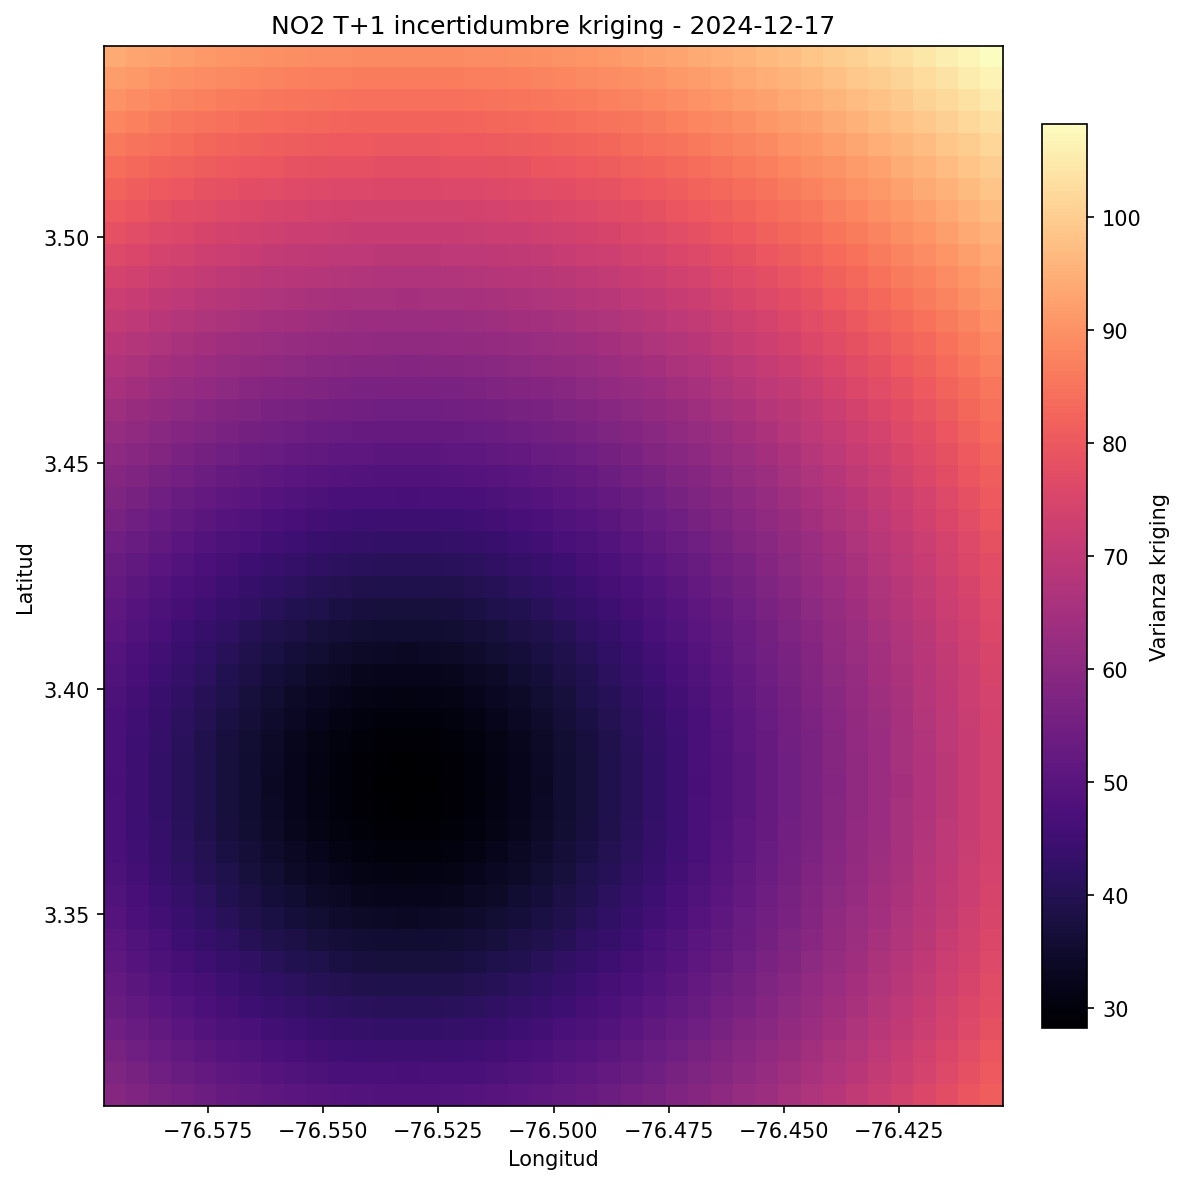

**Interpretacion.** La incertidumbre NO2 debe leerse con especial cautela porque la validacion espacial externa no es defendible por n=1 estacion. La unica estacion con NO2 es Univalle; por eso las zonas alejadas de ese punto tienden a tener mayor varianza y deben leerse como prioridad de monitoreo.

**NO2 T+3 - varianza Kriging**

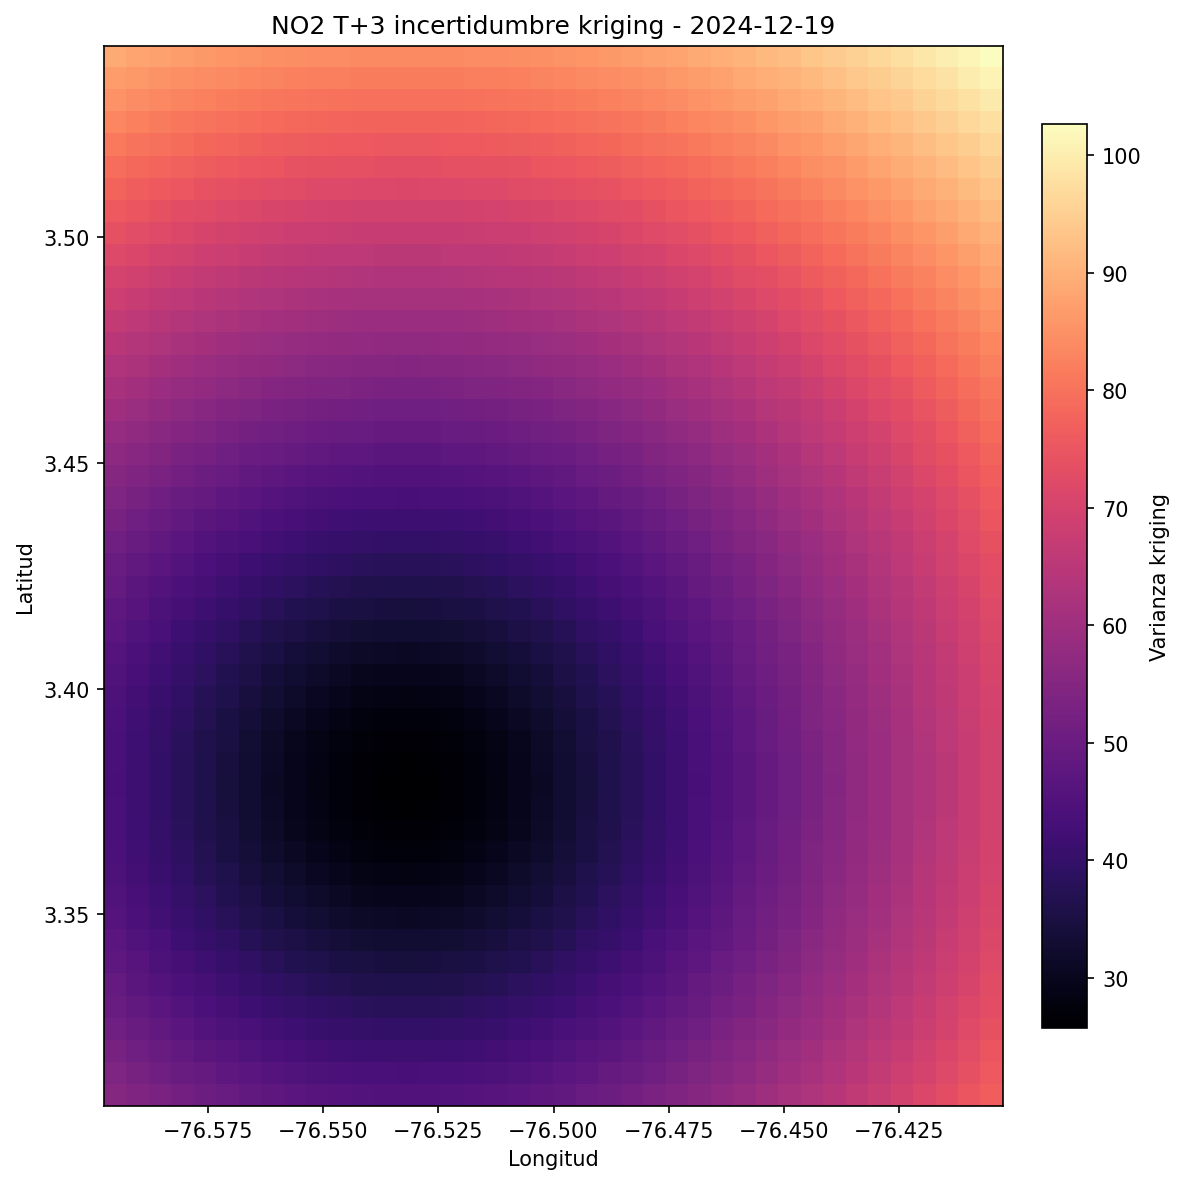

**Interpretacion.** La incertidumbre NO2 debe leerse con especial cautela porque la validacion espacial externa no es defendible por n=1 estacion. La unica estacion con NO2 es Univalle; por eso las zonas alejadas de ese punto tienden a tener mayor varianza y deben leerse como prioridad de monitoreo.

**NO2 T+7 - varianza Kriging**

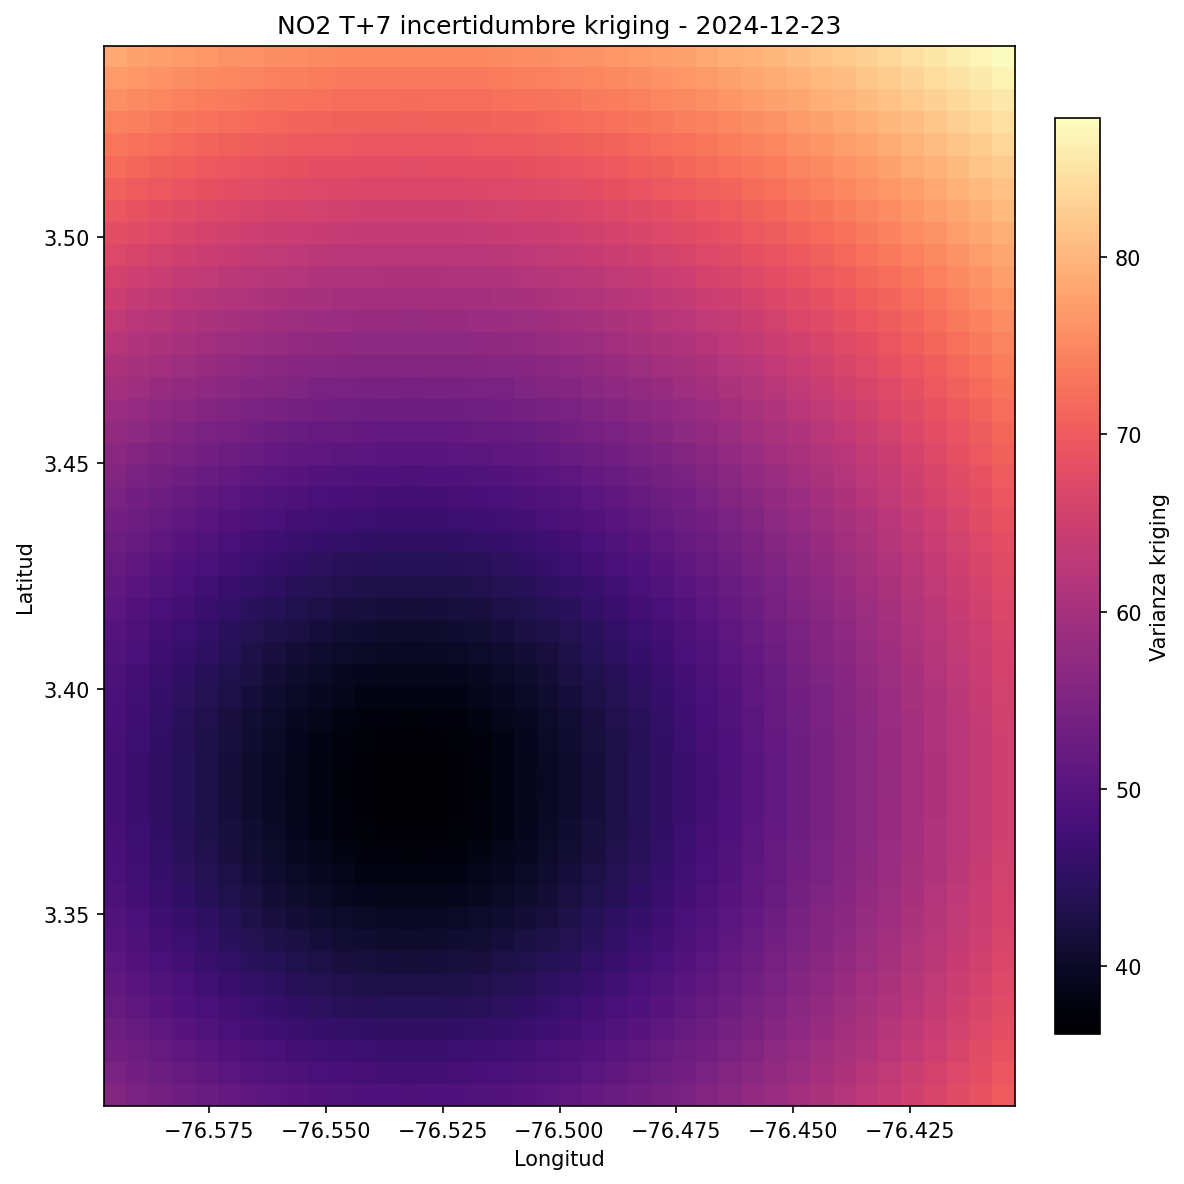

**Interpretacion.** La incertidumbre NO2 debe leerse con especial cautela porque la validacion espacial externa no es defendible por n=1 estacion. La unica estacion con NO2 es Univalle; por eso las zonas alejadas de ese punto tienden a tener mayor varianza y deben leerse como prioridad de monitoreo.

**SO2 T+1 - varianza Kriging**

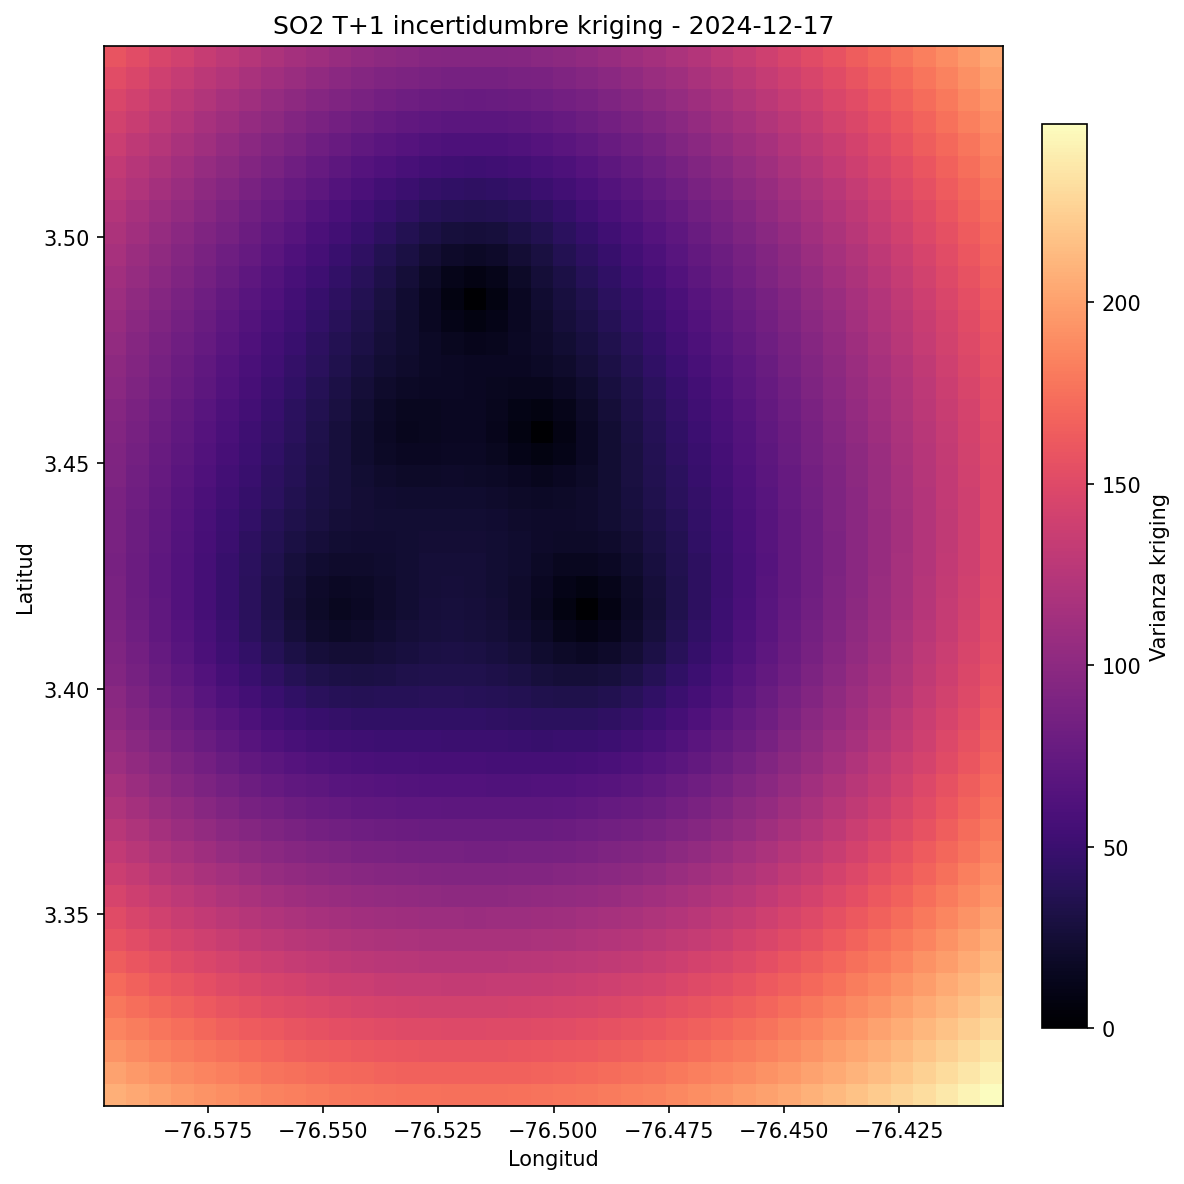

**Interpretacion.** La varianza Kriging de SO2 identifica donde la correccion geoestadistica tiene mayor o menor confianza relativa. Las zonas lejanas a las estaciones SO2 disponibles, especialmente hacia bordes norte-oriente y suroriente, concentran mayor incertidumbre y deben interpretarse con cautela.

**SO2 T+3 - varianza Kriging**

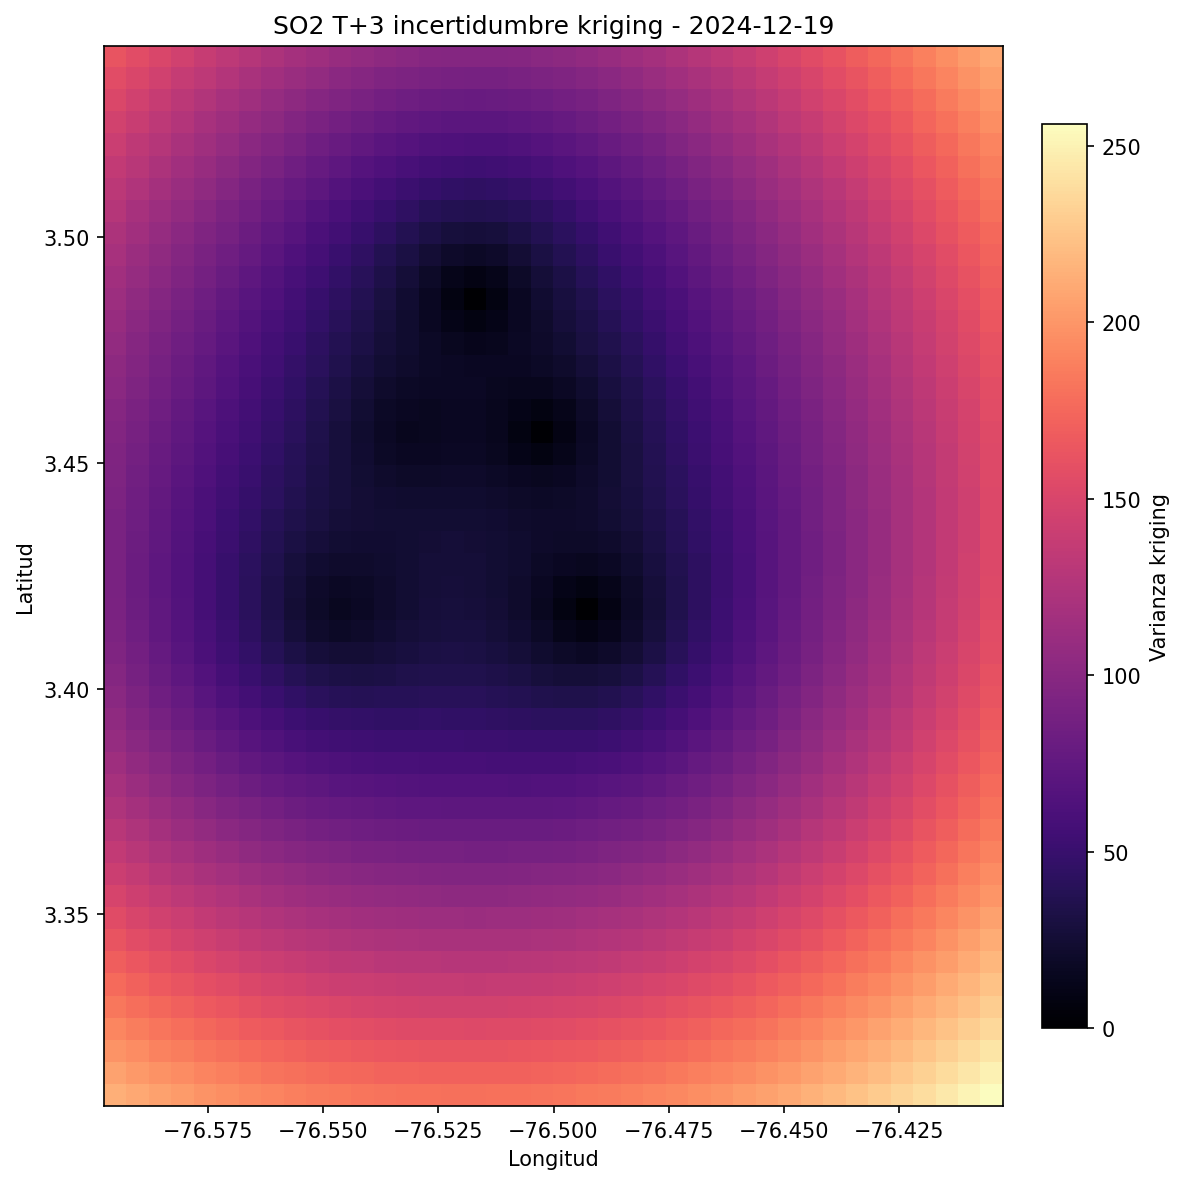

**Interpretacion.** La varianza Kriging de SO2 identifica donde la correccion geoestadistica tiene mayor o menor confianza relativa. Las zonas lejanas a las estaciones SO2 disponibles, especialmente hacia bordes norte-oriente y suroriente, concentran mayor incertidumbre y deben interpretarse con cautela.

**SO2 T+7 - varianza Kriging**

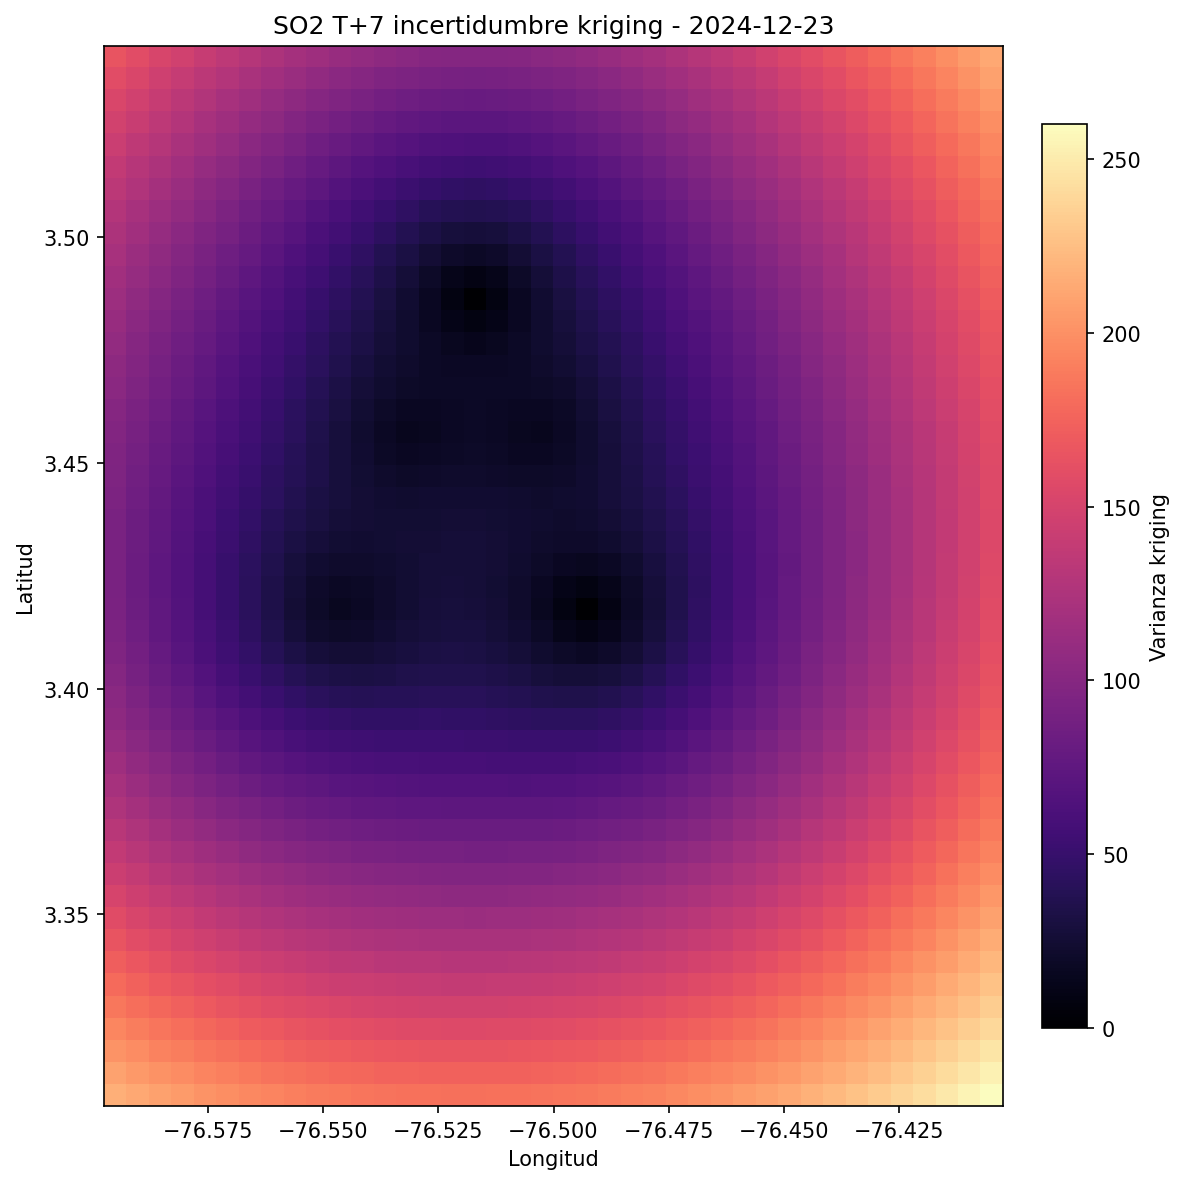

**Interpretacion.** La varianza Kriging de SO2 identifica donde la correccion geoestadistica tiene mayor o menor confianza relativa. Las zonas lejanas a las estaciones SO2 disponibles, especialmente hacia bordes norte-oriente y suroriente, concentran mayor incertidumbre y deben interpretarse con cautela.

**O3 T+1 - varianza Kriging**

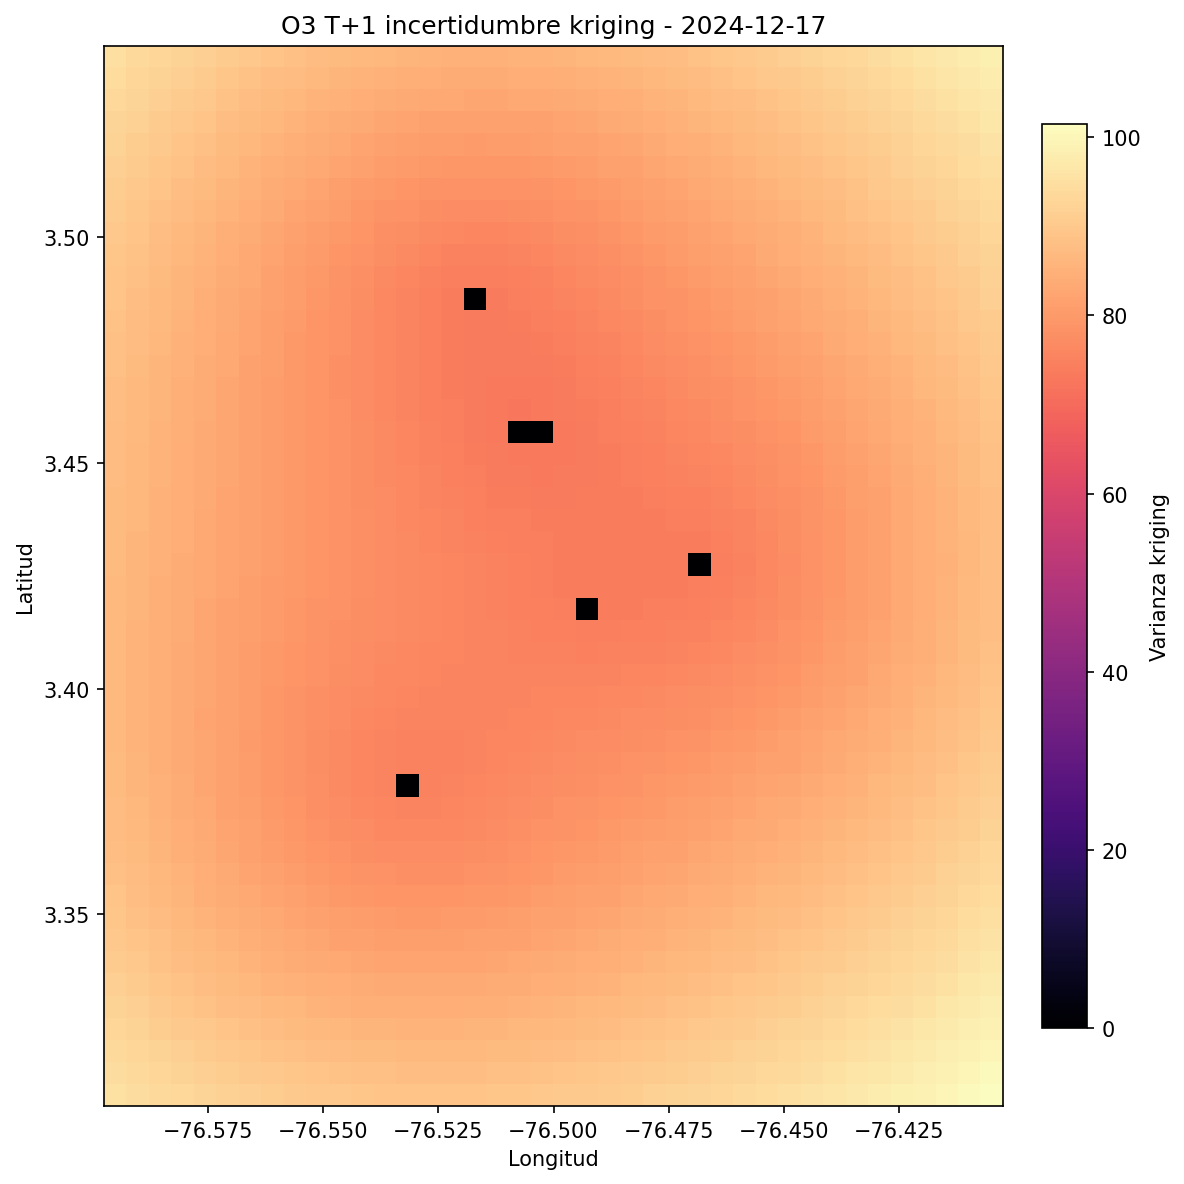

**Interpretacion.** La varianza Kriging de O3 acompana una superficie mas heterogenea. Aunque O3 tiene mas estaciones de soporte que NO2 y SO2, las zonas alejadas de estaciones siguen requiriendo lectura prudente.

**O3 T+3 - varianza Kriging**

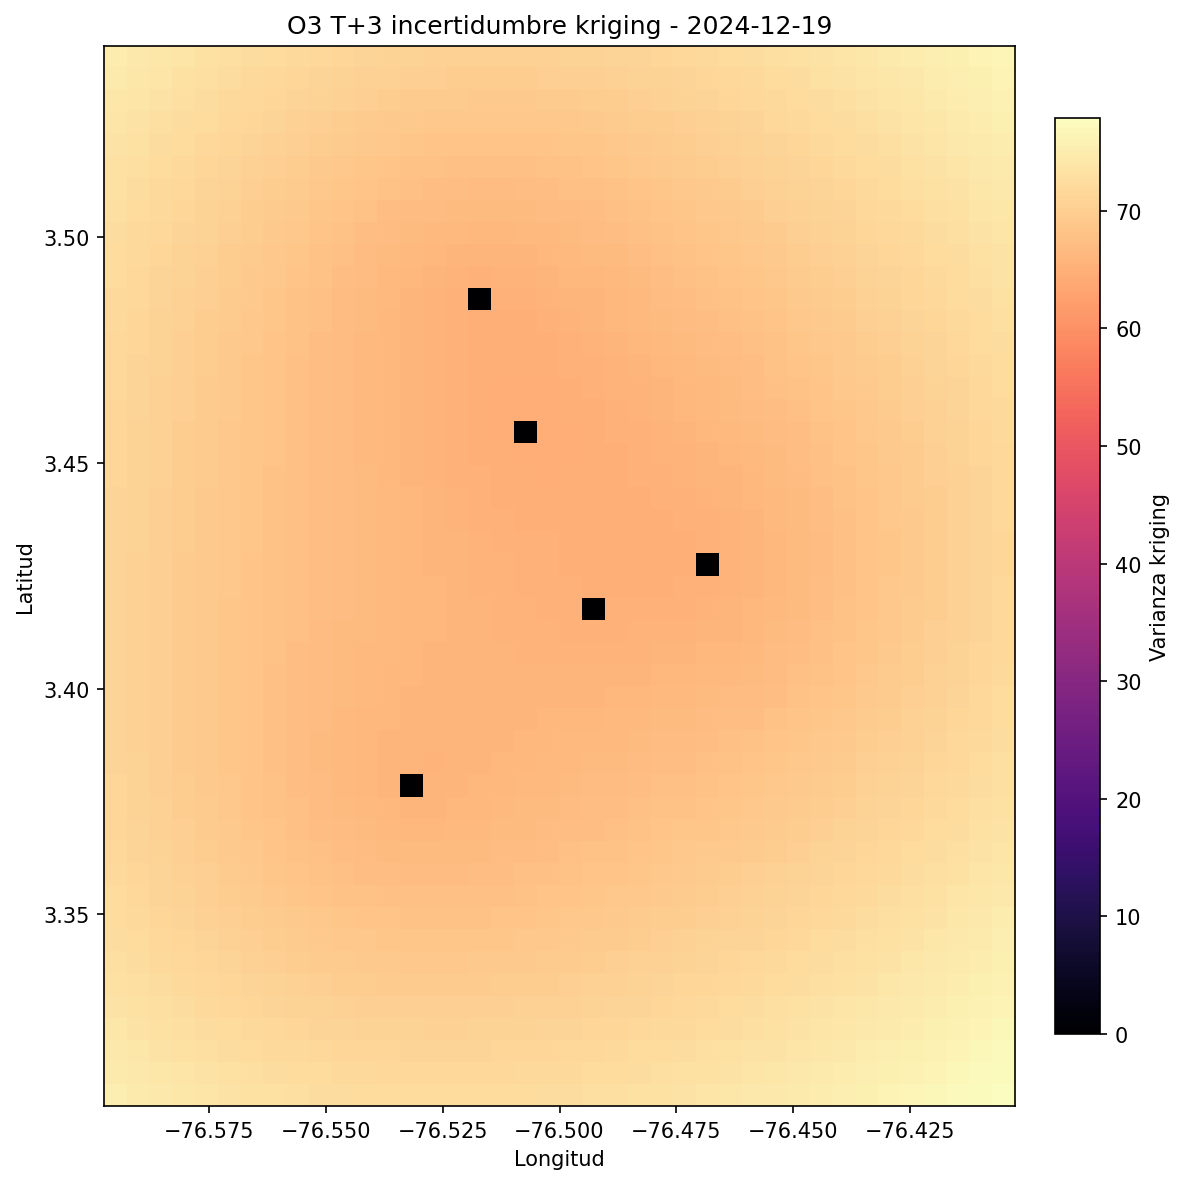

**Interpretacion.** La varianza Kriging de O3 acompana una superficie mas heterogenea. Aunque O3 tiene mas estaciones de soporte que NO2 y SO2, las zonas alejadas de estaciones siguen requiriendo lectura prudente.

**O3 T+7 - varianza Kriging**

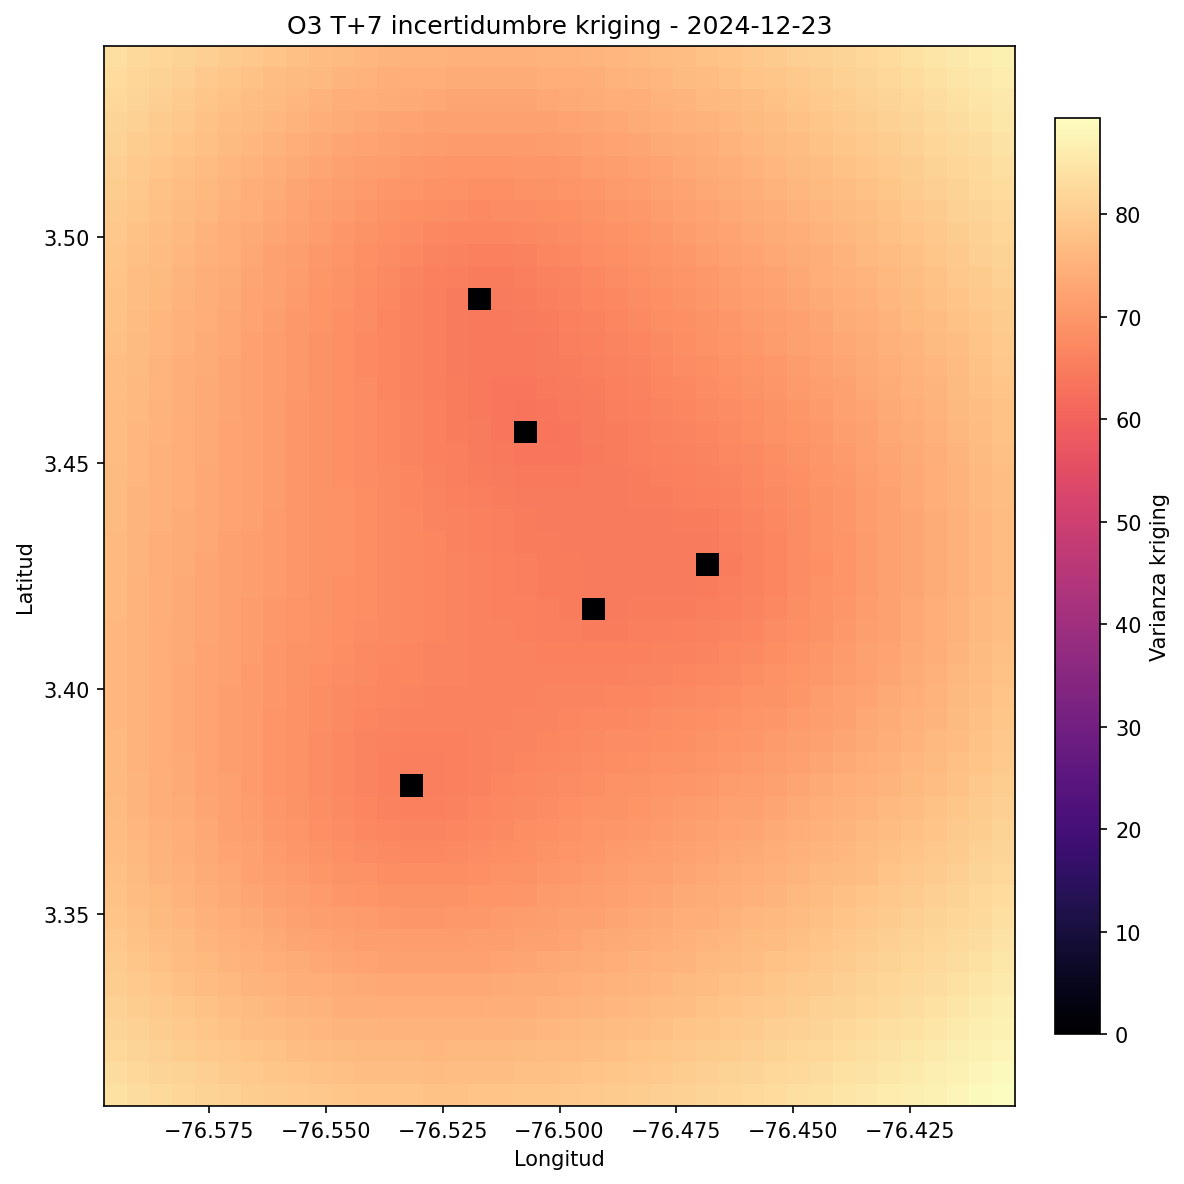

**Interpretacion.** La varianza Kriging de O3 acompana una superficie mas heterogenea. Aunque O3 tiene mas estaciones de soporte que NO2 y SO2, las zonas alejadas de estaciones siguen requiriendo lectura prudente.

### LISA local

#### LISA NO2

**NO2 T+1**

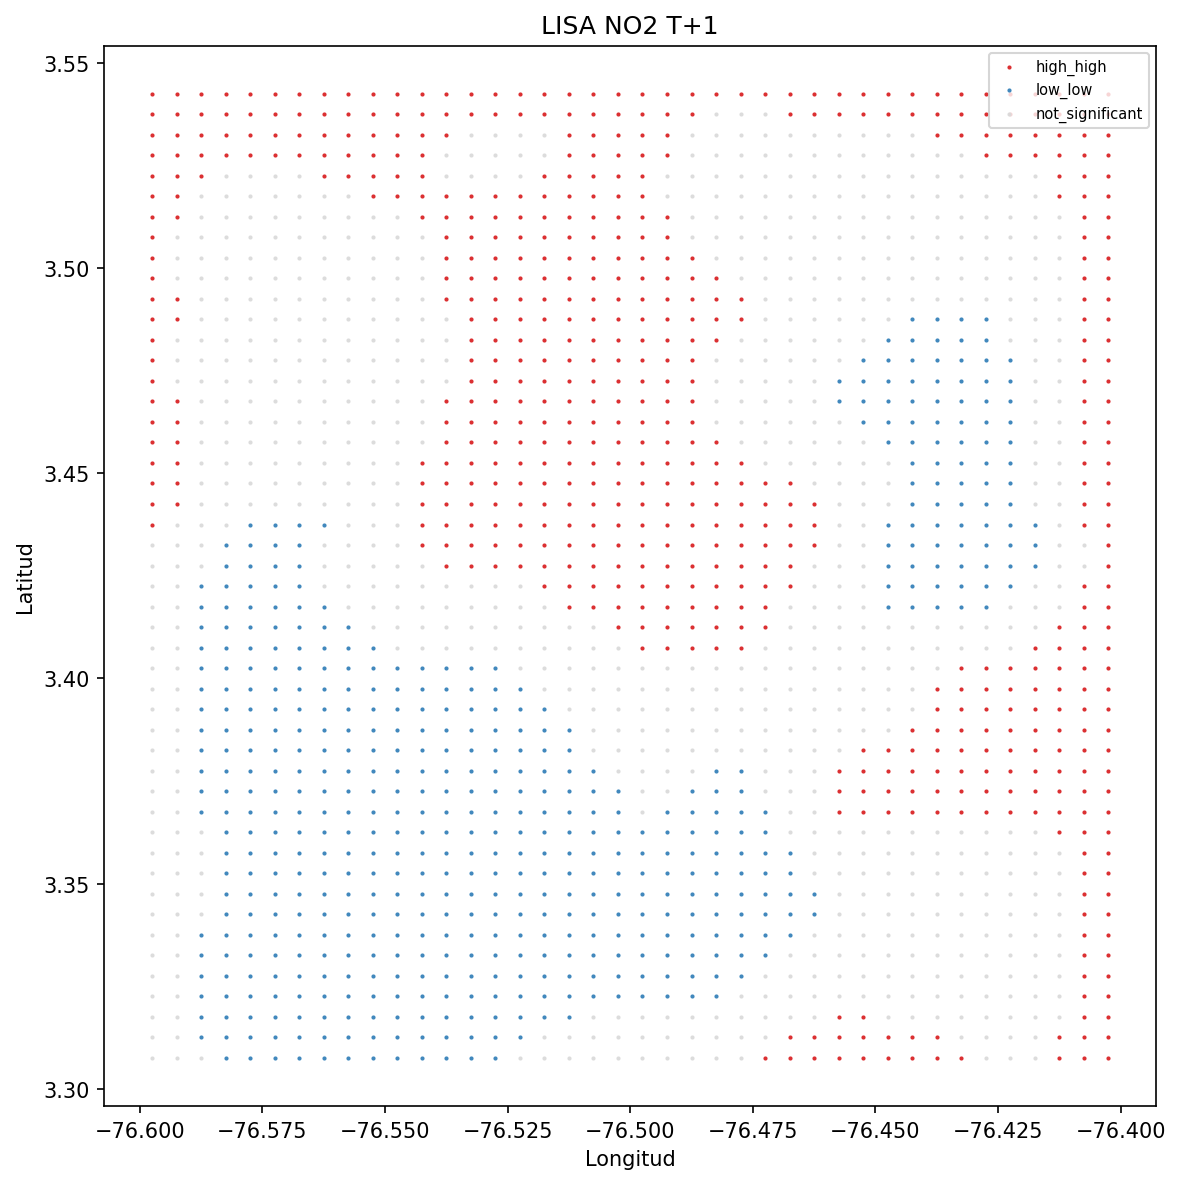

**NO2 T+3**

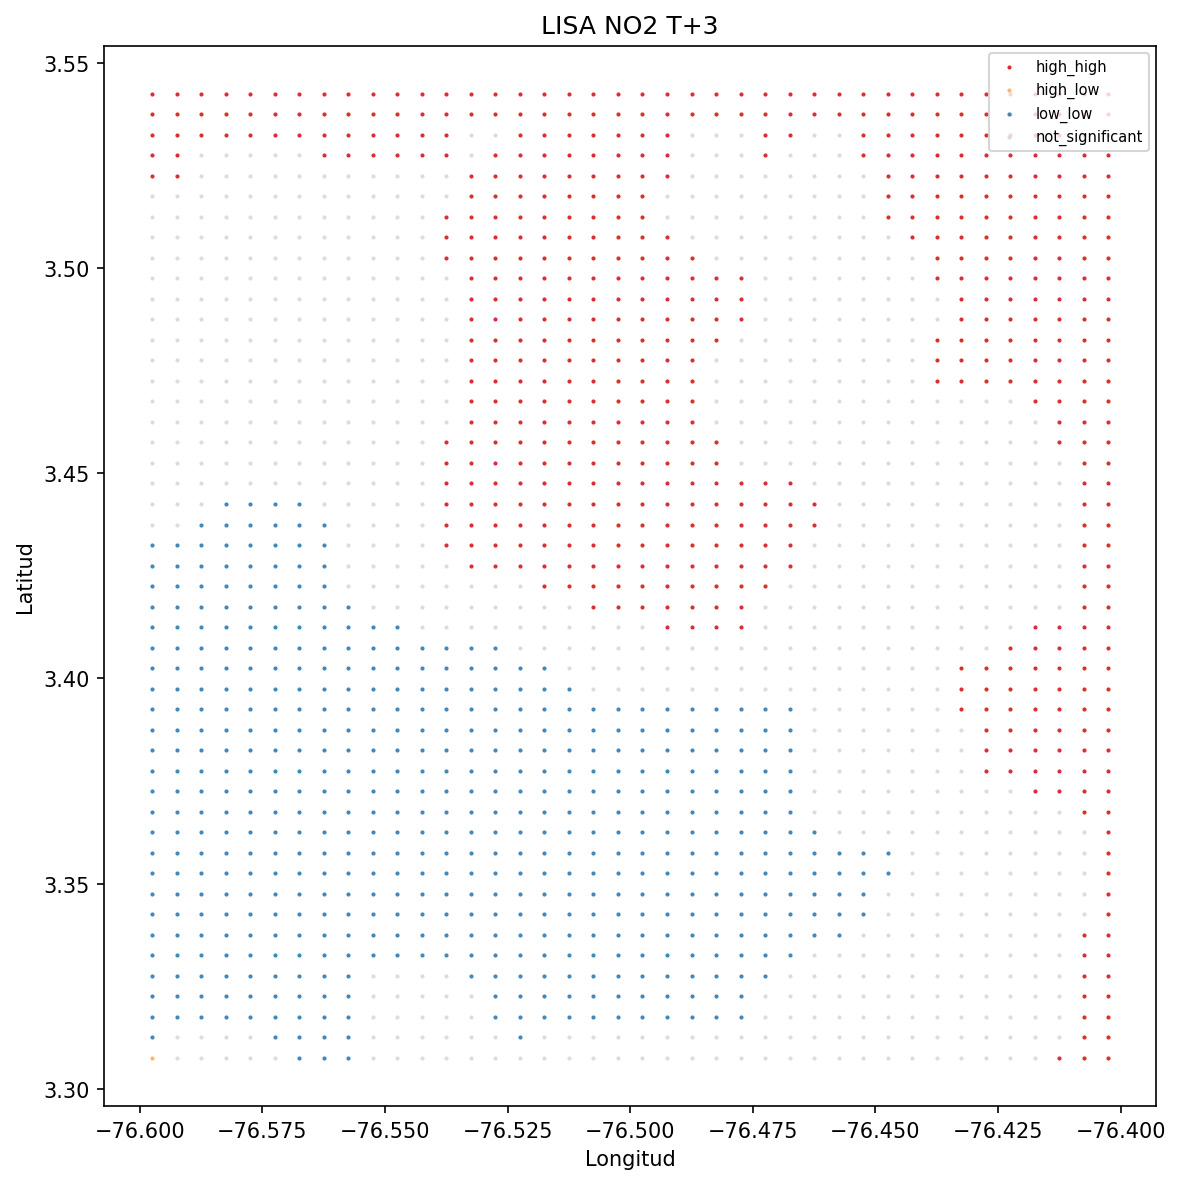

**NO2 T+7**

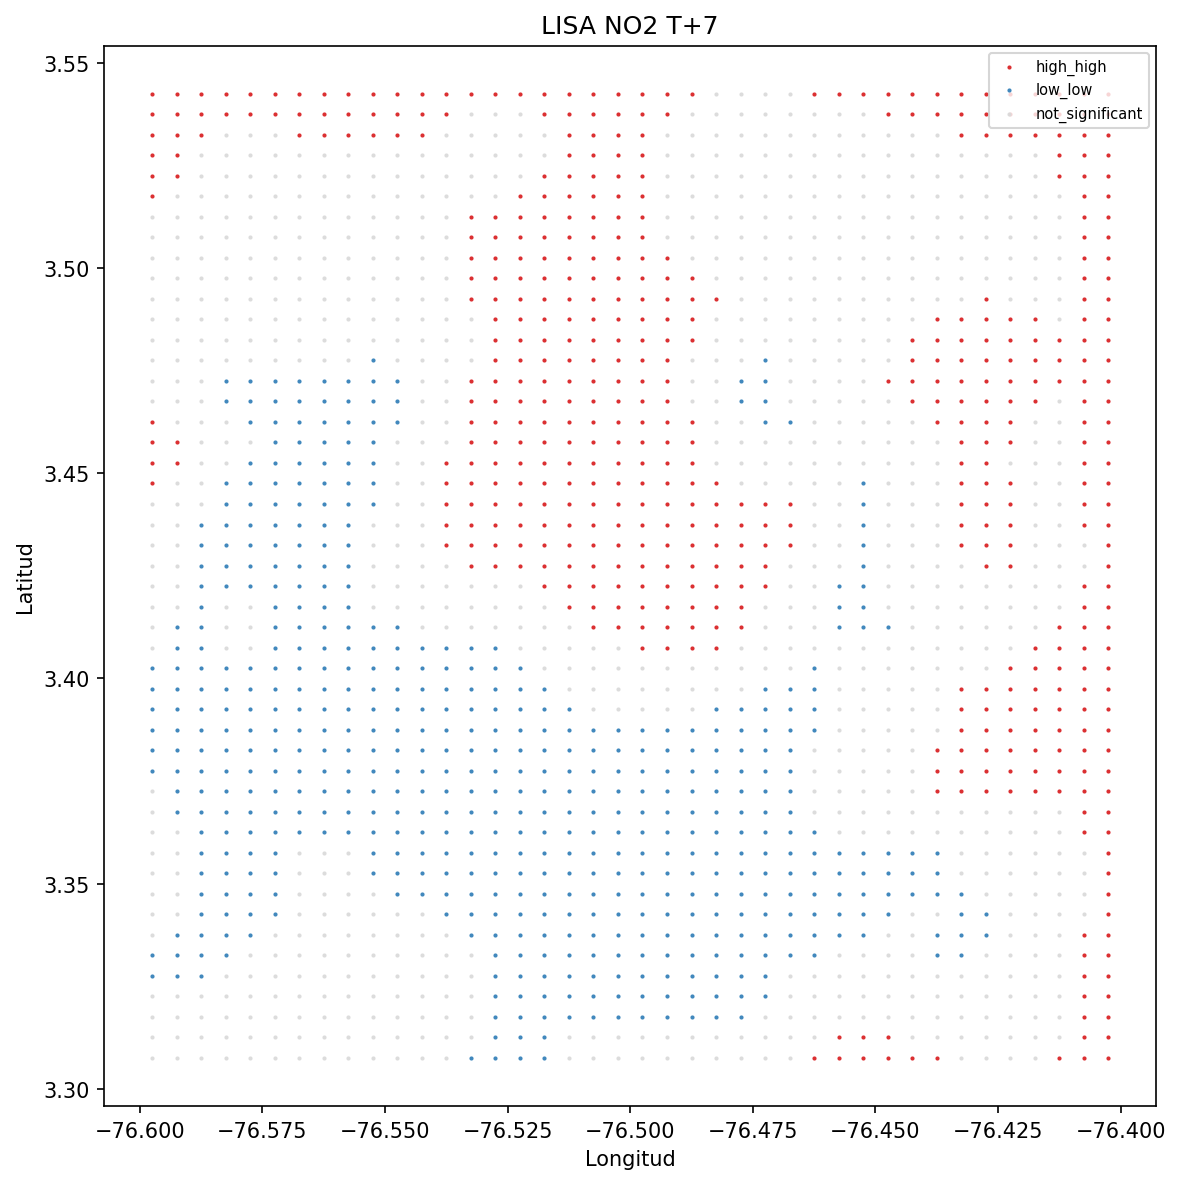

**Interpretacion.** En NO2, los clusters high_high se agrupan hacia el norte y nororiente, mientras que los low_low aparecen con mayor fuerza hacia el suroccidente. El patron es espacialmente coherente, pero esta condicionado por una red muy debil para este gas: solo Univalle aporta medicion directa de NO2. Por eso el mapa sirve mejor para ubicar zonas donde convendria ampliar monitoreo, especialmente hacia el norte/nororiente, que como estimacion validada externamente.

#### LISA SO2

**SO2 T+1**

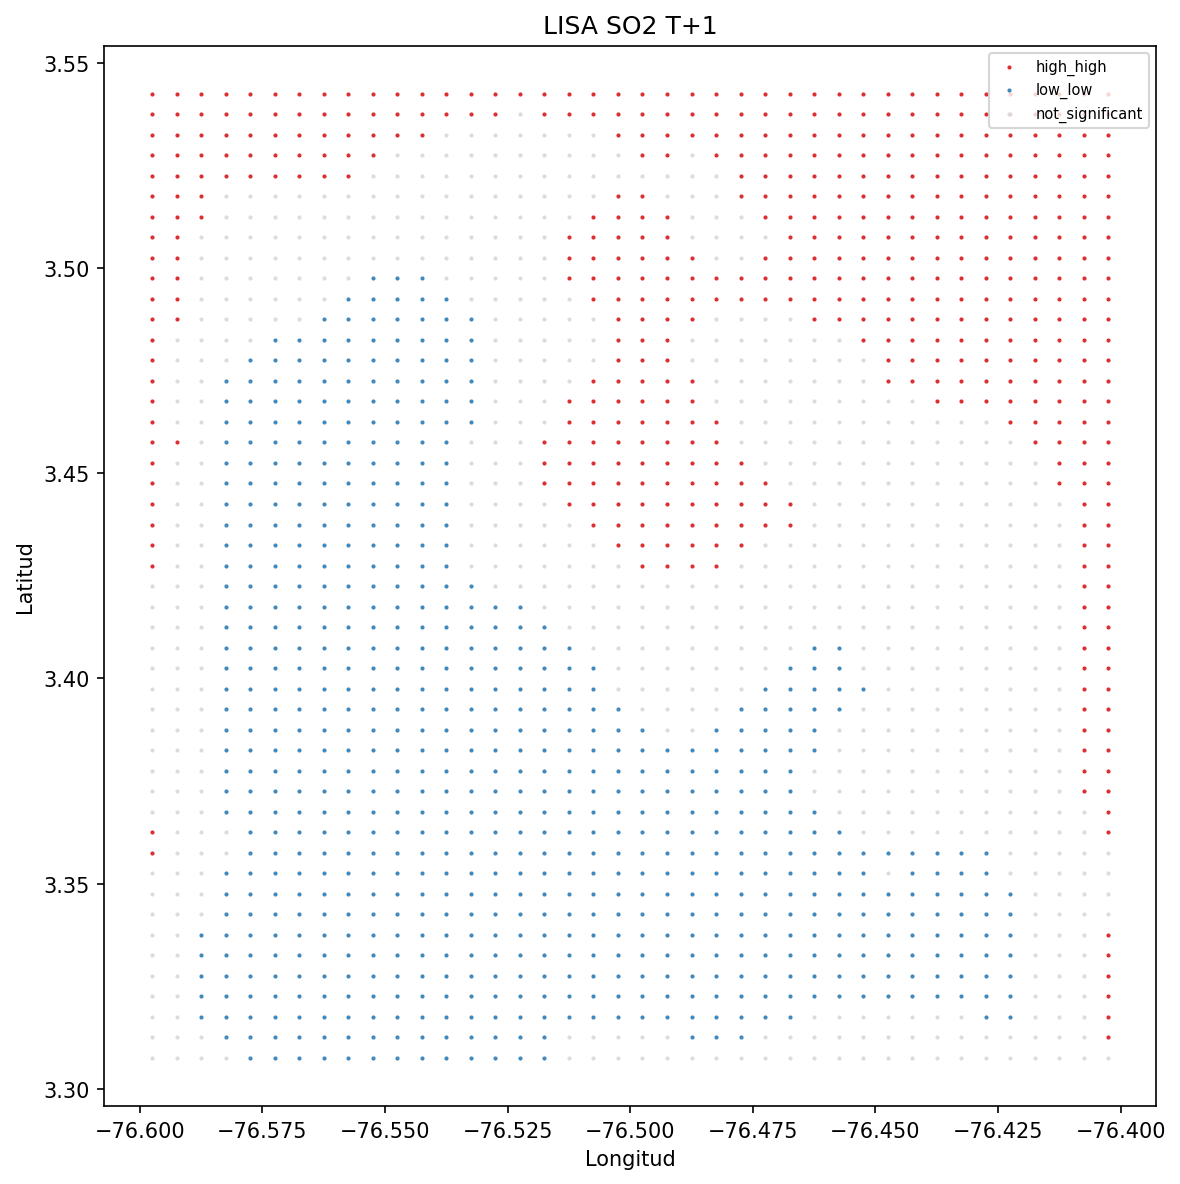

**SO2 T+3**

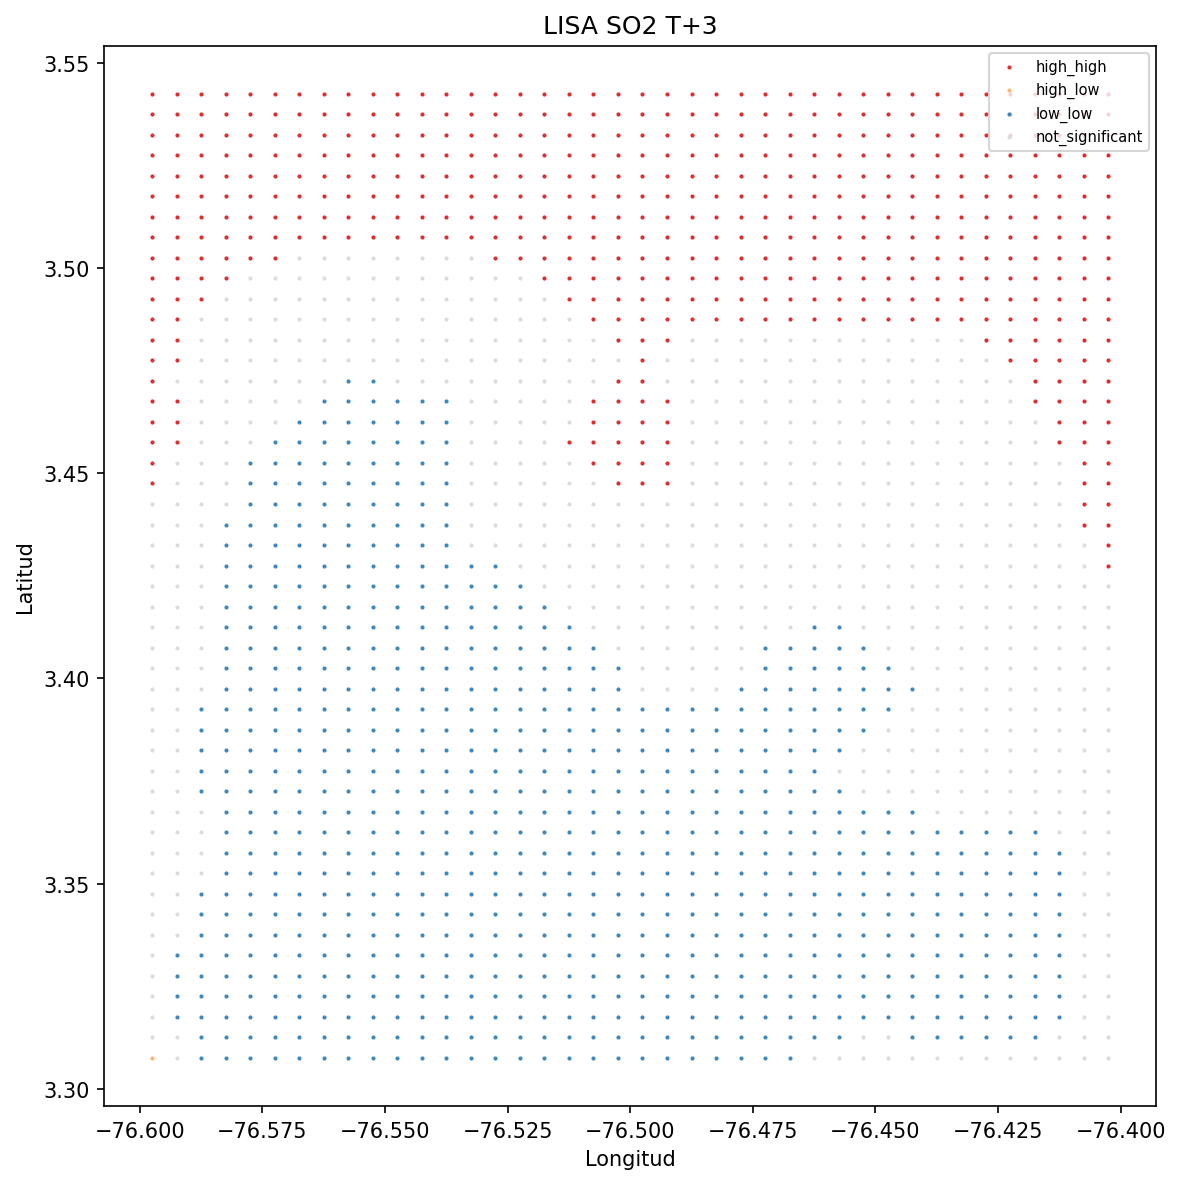

**SO2 T+7**

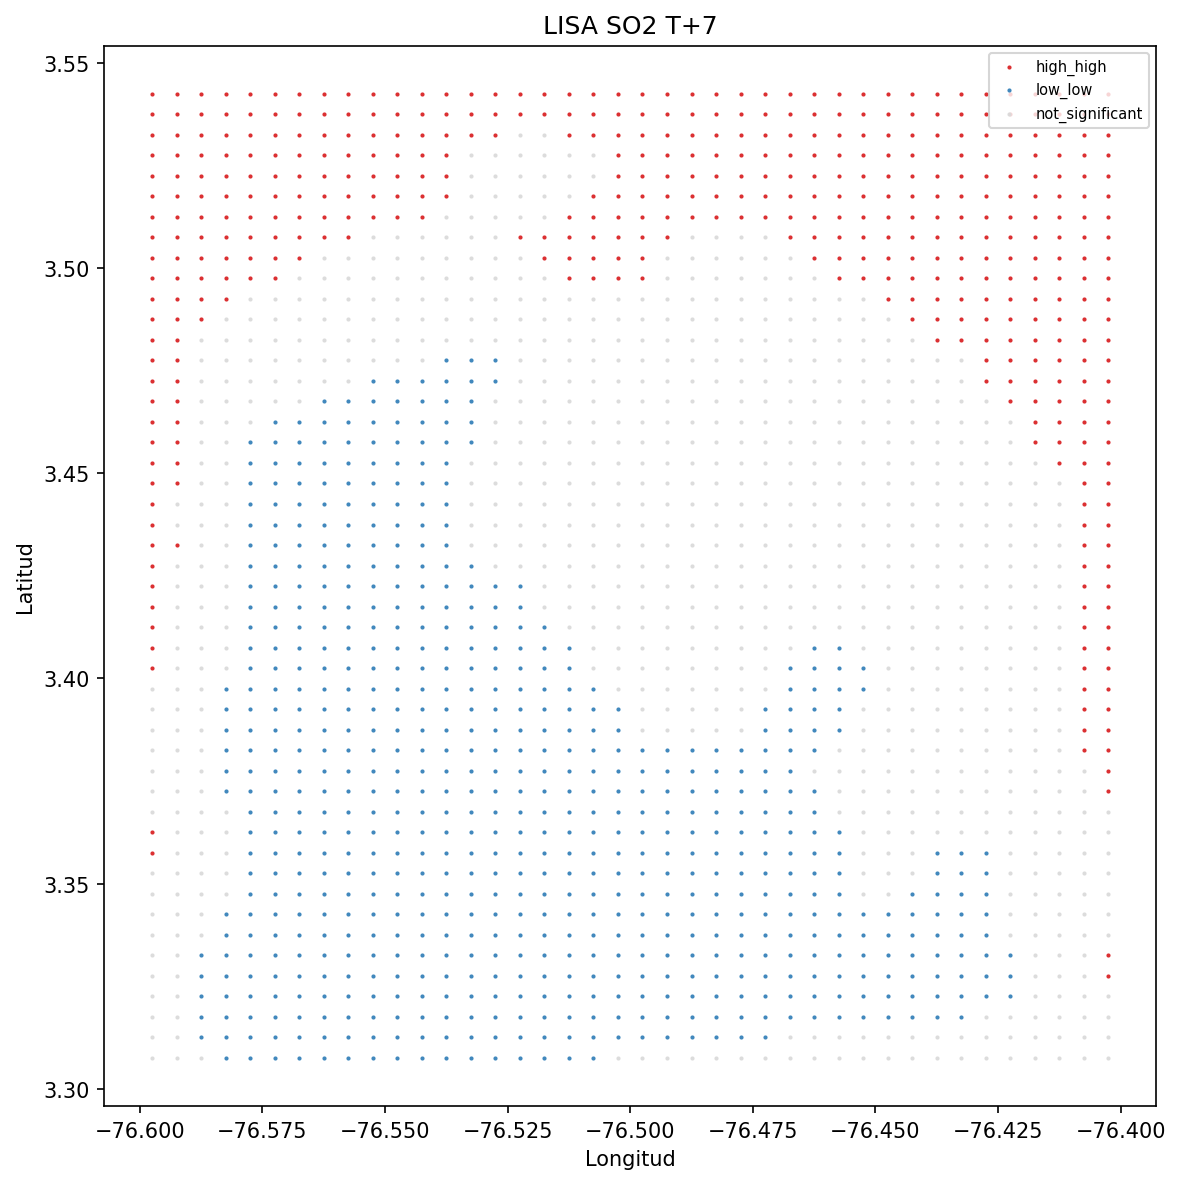

**Interpretacion.** SO2 muestra el patron mas defendible de LISA: clusters high_high persistentes hacia el norte/nororiente y low_low hacia el suroccidente. A diferencia de NO2, este gas si tiene soporte de varias estaciones y cumple el umbral LOO-CV, por lo que la lectura espacial es mas solida. La zona alta coincide con el borde metropolitano hacia Yumbo/Acopi, un corredor industrial reconocido en la region, lo que da sentido territorial al patron sin convertirlo en atribucion causal.

#### LISA O3

**O3 T+1**

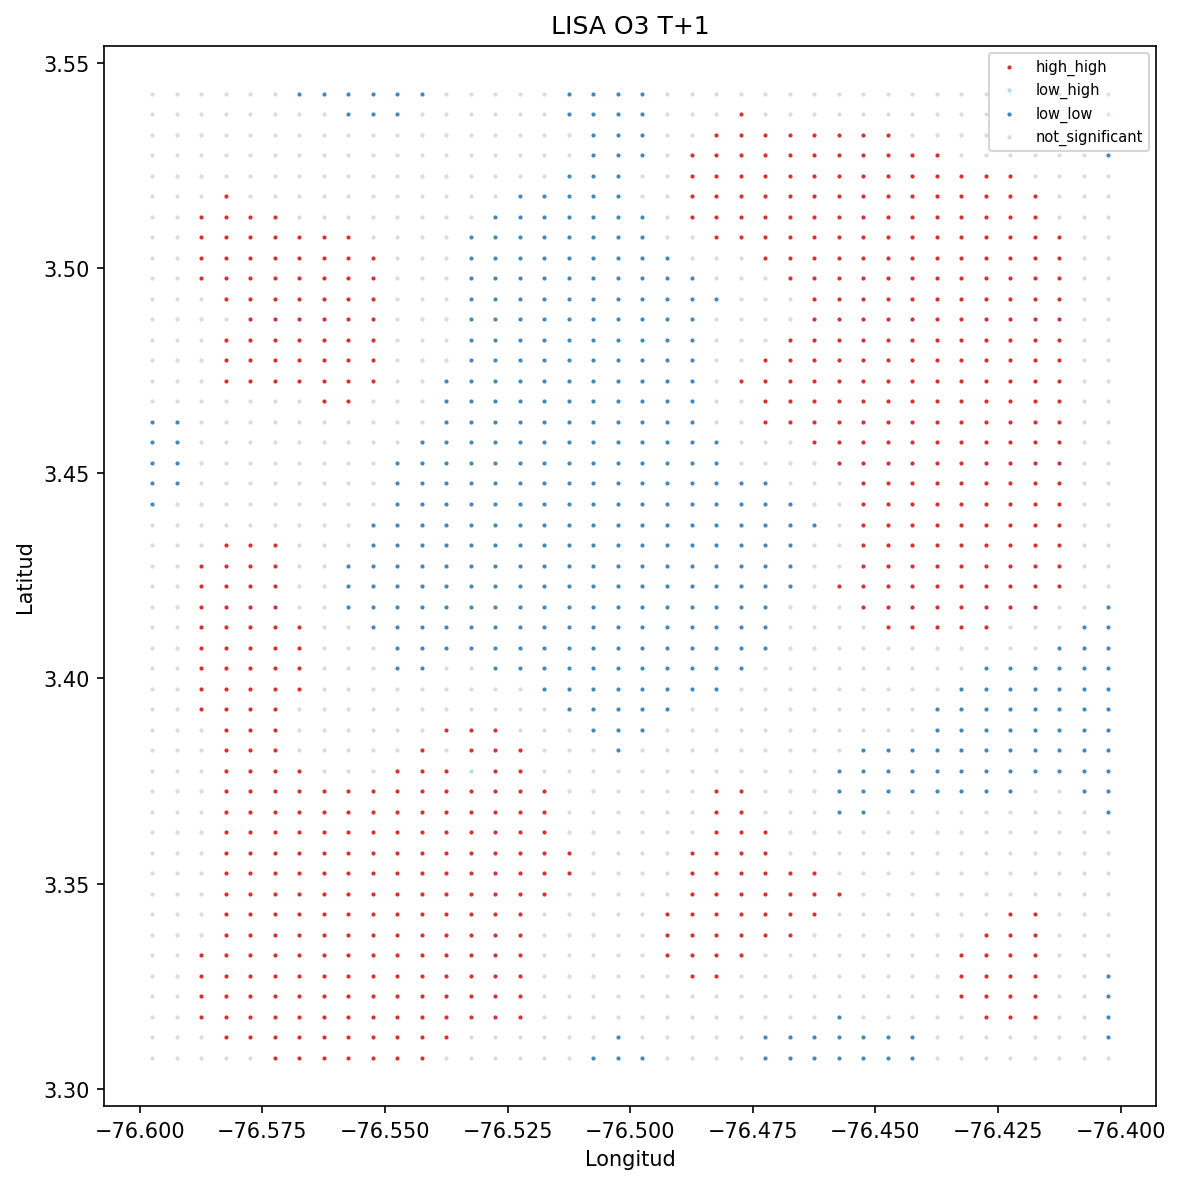

**O3 T+3**

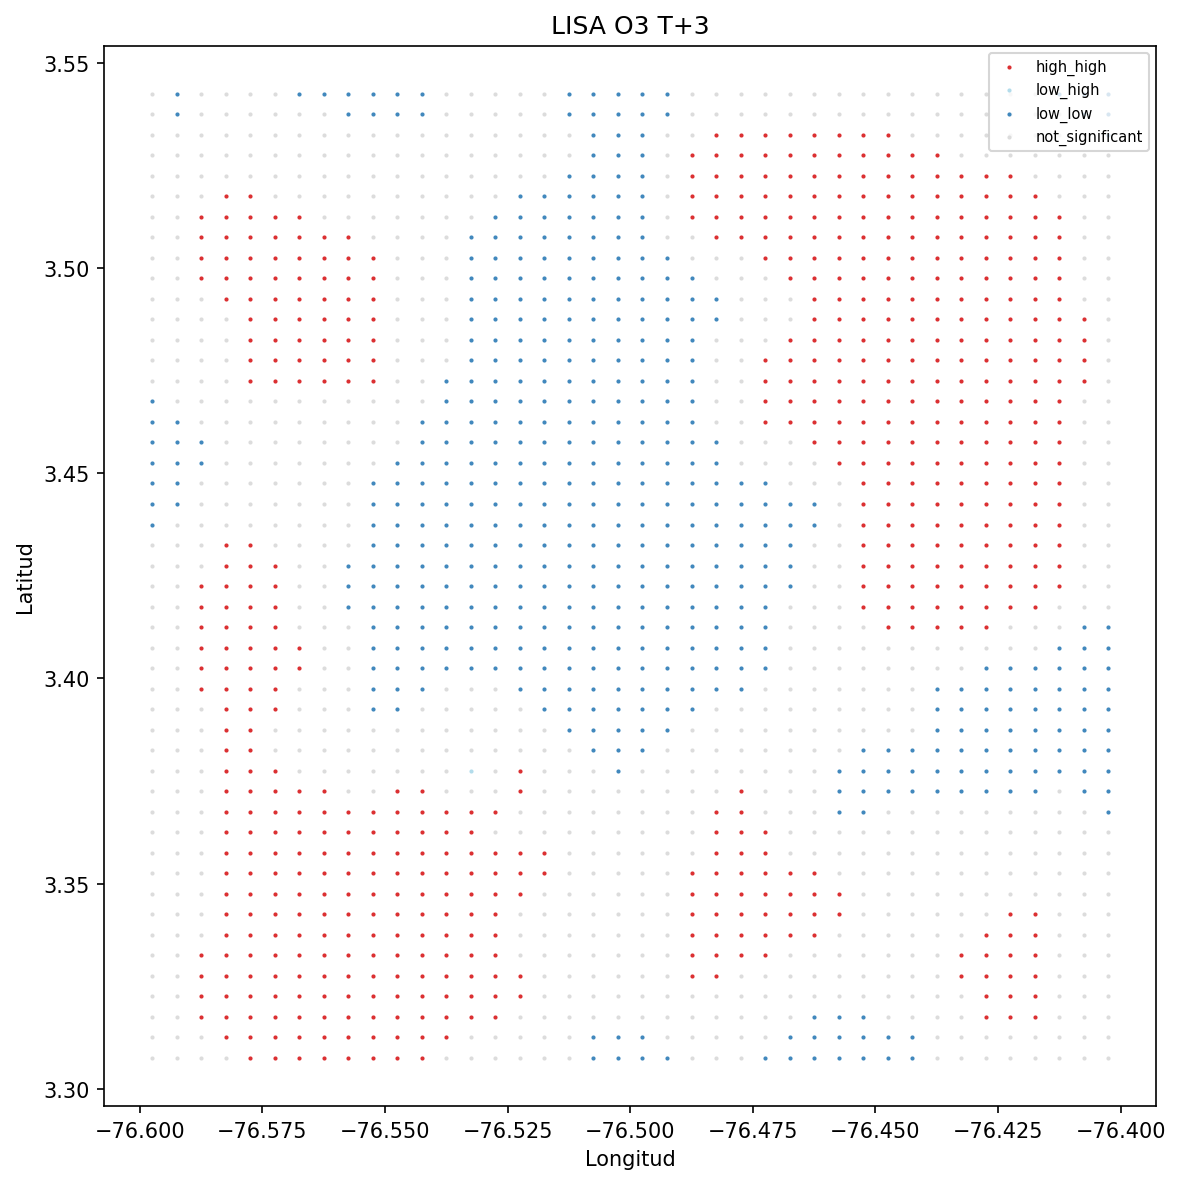

**O3 T+7**

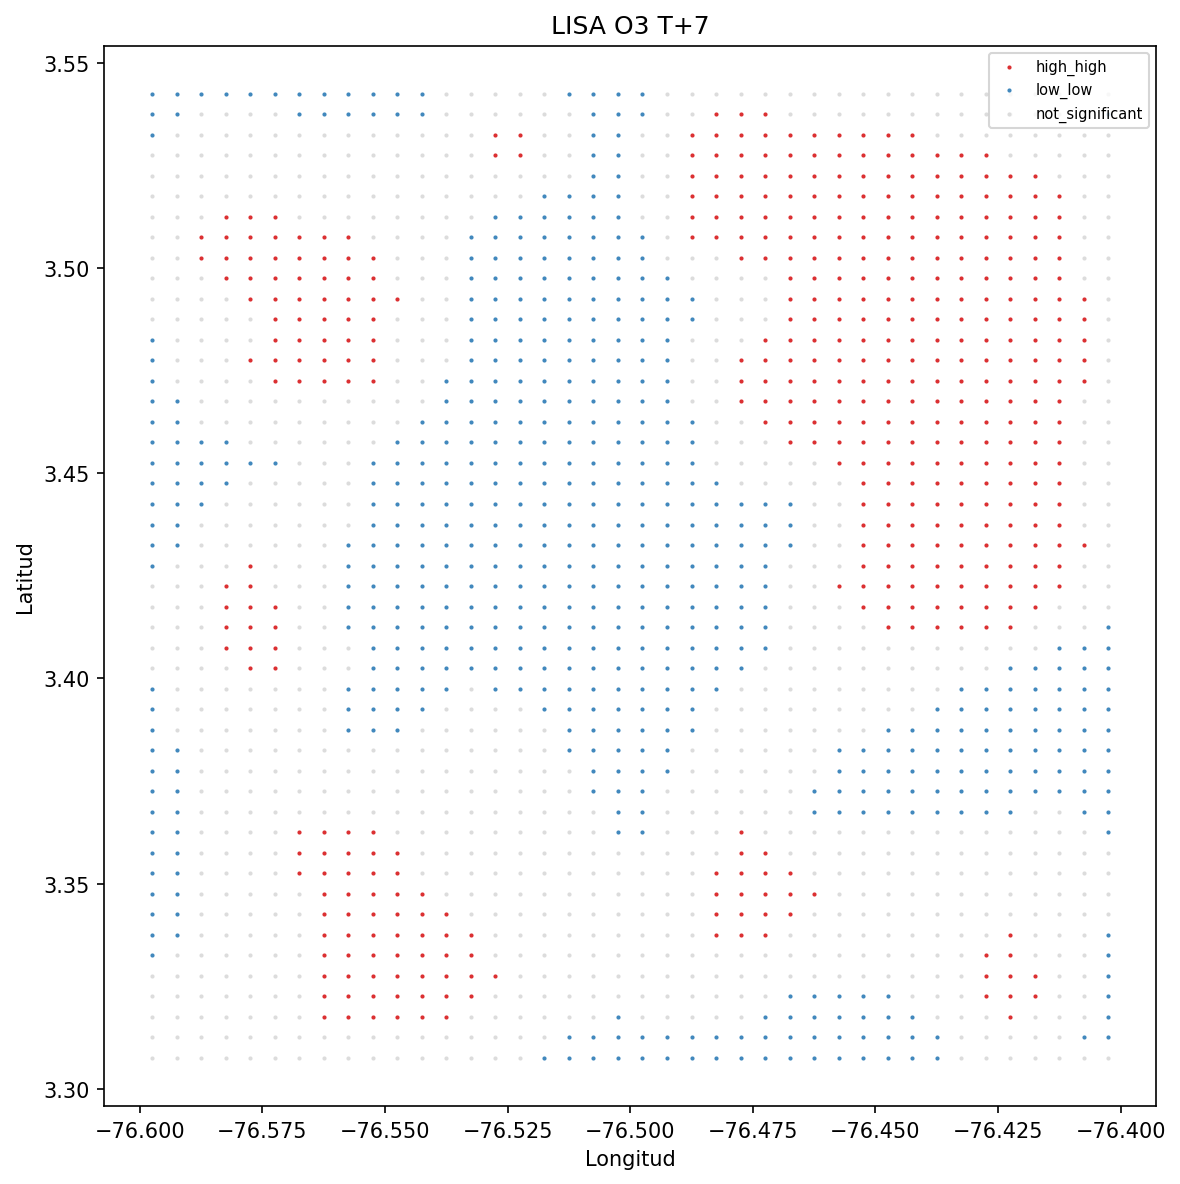

**Interpretacion.** O3 no forma un unico foco dominante. Sus clusters high_high y low_low aparecen mas fragmentados, lo cual es consistente con un contaminante secundario que depende de radiacion, meteorologia, precursores y cobertura del suelo. La lectura no debe buscar una fuente puntual, sino zonas donde las condiciones urbanas, vegetacion/suelo y transporte regional favorecen acumulacion relativa de ozono.

### K-Means perfiles criticos

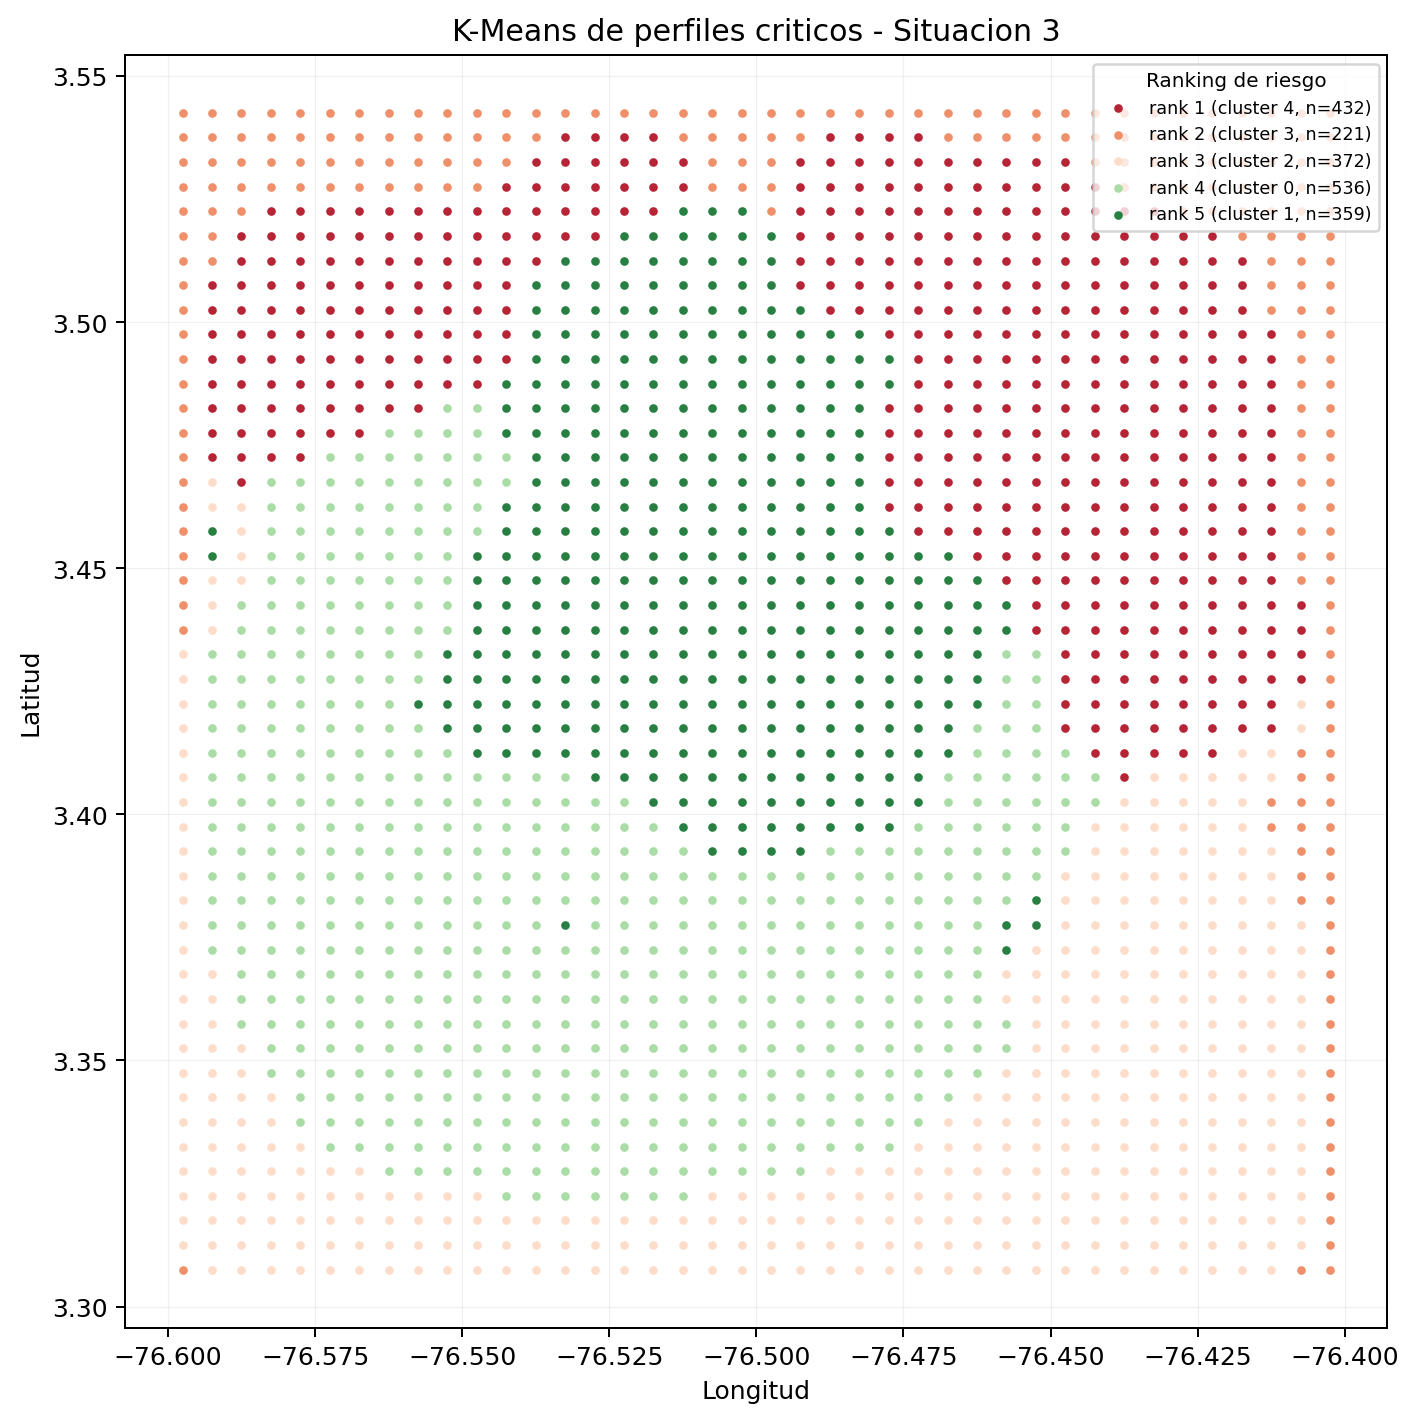

,cluster,nombre_perfil,risk_rank,n_cells,mean_prediction_profile,max_prediction_profile,mean_uncertainty_profile,lat_mean,lon_mean
0,4,norte/nororiente industrial de mayor riesgo,1,432,18.060950,38.297096,81.109320,3.486748,-76.479896
1,3,riesgo alto con incertidumbre alta,2,221,17.098700,28.882643,102.297502,3.494966,-76.477704
2,2,riesgo medio con incertidumbre alta,3,372,14.337492,31.795226,99.677946,3.344973,-76.482997
3,0,fondo urbano relativo intermedio,4,536,14.096493,34.490131,66.590639,3.384366,-76.531996
4,1,fondo urbano relativo bajo,5,359,13.015160,23.991048,50.108718,3.451219,-76.507765


**Interpretacion.** K-Means resume los nueve mapas en cinco perfiles territoriales. El cluster 4 se nombra como **norte/nororiente industrial de mayor riesgo** porque combina la media de prediccion mas alta, maximos elevados y un centro hacia el borde norte/nororiental de Cali, cercano al corredor Yumbo/Acopi. El cluster 3 se nombra **riesgo alto con incertidumbre alta**: no solo presenta valores altos, tambien concentra la mayor incertidumbre media, por lo que marca una zona prioritaria para reforzar monitoreo. El cluster 2 funciona como **riesgo medio con incertidumbre alta**, mientras que los clusters 0 y 1 representan fondos urbanos relativos de menor severidad. La utilidad de K-Means no es probar causalidad, sino separar perfiles cronicos de riesgo, incertidumbre y soporte espacial para orientar decisiones territoriales.

In [11]:
fig_summary = read_json(FIG / 'summary_final_map_figures.json')
show_json({'n_png': fig_summary.get('n_png'), 'out': fig_summary.get('out')})

pred_interpretacion_gas = {
    'NO2': 'Los tres horizontes de NO2 conservan una estructura espacial persistente, con zonas relativamente altas hacia el norte/nororiente y menores valores hacia el suroccidente. La lectura principal es de patron territorial estable, no de validacion externa fuerte, porque el soporte directo de estaciones para NO2 proviene solo de Univalle.',
    'SO2': 'SO2 presenta el patron mas defendible de concentracion corregida: los tres horizontes mantienen un gradiente alto hacia el norte/nororiente y menor carga hacia el suroccidente. Esta lectura es consistente con la validacion LOO-CV y con el contexto del corredor industrial Yumbo/Acopi.',
    'O3': 'O3 muestra una distribucion mas heterogenea entre horizontes, sin un unico foco dominante. Esto es coherente con su caracter de contaminante secundario, asociado a radiacion, meteorologia, precursores y cobertura de suelo/vegetacion. La interpretacion debe centrarse en acumulacion regional y condiciones ambientales, no en una fuente puntual.',
}
var_interpretacion = {
    'NO2': 'La incertidumbre NO2 debe leerse con especial cautela porque la validacion espacial externa no es defendible por n=1 estacion. La unica estacion con NO2 es Univalle; por eso las zonas alejadas de ese punto tienden a tener mayor varianza y deben leerse como prioridad de monitoreo.',
    'SO2': 'La varianza Kriging de SO2 identifica donde la correccion geoestadistica tiene mayor o menor confianza relativa. Las zonas lejanas a las estaciones SO2 disponibles, especialmente hacia bordes norte-oriente y suroriente, concentran mayor incertidumbre y deben interpretarse con cautela.',
    'O3': 'La varianza Kriging de O3 acompana una superficie mas heterogenea. Aunque O3 tiene mas estaciones de soporte que NO2 y SO2, las zonas alejadas de estaciones siguen requiriendo lectura prudente.',
}

lisa_interpretacion_gas = {
    'NO2': 'En NO2, los clusters high_high se agrupan hacia el norte y nororiente, mientras que los low_low aparecen con mayor fuerza hacia el suroccidente. El patron es espacialmente coherente, pero esta condicionado por una red muy debil para este gas: solo Univalle aporta medicion directa de NO2. Por eso el mapa sirve mejor para ubicar zonas donde convendria ampliar monitoreo, especialmente hacia el norte/nororiente, que como estimacion validada externamente.',
    'SO2': 'SO2 muestra el patron mas defendible de LISA: clusters high_high persistentes hacia el norte/nororiente y low_low hacia el suroccidente. A diferencia de NO2, este gas si tiene soporte de varias estaciones y cumple el umbral LOO-CV, por lo que la lectura espacial es mas solida. La zona alta coincide con el borde metropolitano hacia Yumbo/Acopi, un corredor industrial reconocido en la region, lo que da sentido territorial al patron sin convertirlo en atribucion causal.',
    'O3': 'O3 no forma un unico foco dominante. Sus clusters high_high y low_low aparecen mas fragmentados, lo cual es consistente con un contaminante secundario que depende de radiacion, meteorologia, precursores y cobertura del suelo. La lectura no debe buscar una fuente puntual, sino zonas donde las condiciones urbanas, vegetacion/suelo y transporte regional favorecen acumulacion relativa de ozono.',
}

kmeans_profile_names = {
    4: 'norte/nororiente industrial de mayor riesgo',
    3: 'riesgo alto con incertidumbre alta',
    2: 'riesgo medio con incertidumbre alta',
    0: 'fondo urbano relativo intermedio',
    1: 'fondo urbano relativo bajo',
}
for pollutant in ['NO2', 'SO2', 'O3']:
    display(Markdown(f'### {pollutant} - concentracion corregida'))
    for horizon in [1, 3, 7]:
        img = FIG / 'prediction_corrected' / f'map_{pollutant}_t{horizon}_prediction_corrected.png'
        if img.exists():
            display(Markdown(f'**{pollutant} T+{horizon} - concentracion corregida**'))
            display(Image(filename=str(img)))
    display(Markdown('**Interpretacion.** ' + pred_interpretacion_gas[pollutant]))

display(Markdown('### Incertidumbre Kriging'))
for pollutant in ['NO2', 'SO2', 'O3']:
    for horizon in [1, 3, 7]:
        img = FIG / 'kriging_variance' / f'map_{pollutant}_t{horizon}_kriging_variance.png'
        if img.exists():
            display(Markdown(f'**{pollutant} T+{horizon} - varianza Kriging**'))
            display(Image(filename=str(img)))
            display(Markdown('**Interpretacion.** ' + var_interpretacion[pollutant]))

display(Markdown('### LISA local'))
for pollutant in ['NO2', 'SO2', 'O3']:
    display(Markdown(f'#### LISA {pollutant}'))
    for horizon in [1, 3, 7]:
        img = FIG / 'lisa' / f'lisa_{pollutant}_t{horizon}.png'
        if img.exists():
            display(Markdown(f'**{pollutant} T+{horizon}**'))
            display(Image(filename=str(img)))
    display(Markdown('**Interpretacion.** ' + lisa_interpretacion_gas[pollutant]))

display(Markdown('### K-Means perfiles criticos'))
img = FIG / 'kmeans' / 'kmeans_critical_profiles.png'
if img.exists():
    display(Image(filename=str(img)))
    perfiles = pd.DataFrame([
        {'cluster': k, 'nombre_perfil': v} for k, v in kmeans_profile_names.items()
    ]).merge(clusters, on='cluster', how='left').sort_values('risk_rank')
    display(perfiles[['cluster','nombre_perfil','risk_rank','n_cells','mean_prediction_profile','max_prediction_profile','mean_uncertainty_profile','lat_mean','lon_mean']])
    display(Markdown('**Interpretacion.** K-Means resume los nueve mapas en cinco perfiles territoriales. El cluster 4 se nombra como **norte/nororiente industrial de mayor riesgo** porque combina la media de prediccion mas alta, maximos elevados y un centro hacia el borde norte/nororiental de Cali, cercano al corredor Yumbo/Acopi. El cluster 3 se nombra **riesgo alto con incertidumbre alta**: no solo presenta valores altos, tambien concentra la mayor incertidumbre media, por lo que marca una zona prioritaria para reforzar monitoreo. El cluster 2 funciona como **riesgo medio con incertidumbre alta**, mientras que los clusters 0 y 1 representan fondos urbanos relativos de menor severidad. La utilidad de K-Means no es probar causalidad, sino separar perfiles cronicos de riesgo, incertidumbre y soporte espacial para orientar decisiones territoriales.'))

## 9. Limitaciones Y Cierre

- NO2 no tiene LOO-CV espacial defendible porque solo hay una estacion disponible.
- El variograma residual no cumple globalmente el criterio nugget puro (`1/6`).
- SO2 y O3 si tienen validacion espacial con KPIs minimos cumplidos.
- Moran Global cumple en nivel excelente en 9/9 mapas.
- LISA y K-Means aportan lectura territorial de focos locales y perfiles cronicos.
- La API backend cumple latencia excelente con `28.75 ms` de mediana en `/api/situacion3/radius`.